In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.interpolate as interp
import camb
from camb import model, initialpower
a = np.loadtxt("a_bg.txt")
k = np.loadtxt("k_hme.txt")
h0=0.6898
om=0.29044350092105475
n=-1
h0_alex = 0.735
om_alex = 0.32
c_alex = np.array([-0.110,0.02561])
z_alex = np.linspace(0,1100,150)
a_alex = 1/(1+z_alex)
a_alex = a_alex[::-1]

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.optimize import least_squares
from scipy.integrate import cumulative_trapezoid

class model_independent:
    def __init__(self,c,a,h0,om,n) :
        self.a = a
        self.amin = self.a[0]
        self.amax = self.a[-1]
        self.da = (1-a[0])/a[0]
        self.x = (a-a[0])/(a[-1]-a[0])
        self.h0=h0
        self.om = om
        self.c = c
        self.n = n

        # Alex
        self.h0_alex = 0.735
        # self.om_alex = 0.32 # This is going to be left varied
        self.z_alex = np.linspace(0,1100,2000)
        self.a_alex = 1/(1+self.z_alex)
        self.a_alex = self.a_alex[::-1]
        self.x_alex = (self.a_alex-self.a_alex[0])/(self.a_alex[-1]-self.a_alex[0])
        self.a_alex_min = self.a_alex[0]
        self.a_alex_max = self.a_alex[-1]
        self.da_alex = (1-self.a_alex[0])/self.a_alex[0]
        self.c_alex = np.array([-0.1102, 0.0256]) # New paper, with quasars

        self.norm = self._compute_norm()
        self.norm_alex = self._compute_norm_alex()

    # def _compute_norm(self) :
    #     expf = self.da/(1+self.da*self.x)**2/self.chebs(self.c,2*self.x-1)/self.h0
    #     return expf[-1]
    
    def _compute_norm(self):
        expf = self.da/self.amin**(self.n/2)/(1+self.x*self.da)**(2+self.n/2)/self.chebs(self.c,2*self.x-1)/self.h0
        return expf[-1]
    
    def _compute_norm_alex(self):
        n=-1
        expf = self.da_alex/self.a_alex_min**(n/2)/(1+self.x_alex*self.da_alex)**(2+n/2)/self.chebs(self.c_alex,2*self.x_alex-1)/self.h0_alex
        return expf[-1]

    def chebs (self,c,a) :
        if np.ndim(a) == 0 : # Needed for odeint, for some reason it asigns values outside boundaries
            if a>1 :
                a=1.0
            elif  a<-1 :
                a=-1.0
        x = np.arccos(a)
        result = 0
        for i in range(len(c)) :
            if i ==0 :
                result += (1/np.pi)**(1/2)*c[i]
            else :
                result += (2/np.pi)**(1/2)*c[i]*np.cos(i*x)
        return result
    
    def cheb_recursive(c,x) :
        n = len(c)
        t=np.zeros((n,x.shape[0]))
        # t[0]=(1/np.pi)**(1/2)
        # t[1]=(2/np.pi)**(1/2)*x
        t[0]=1
        t[1]=x
        for i in range(1,n-1) :
            t[i+1]=2*x*t[i]-t[i-1]
        for i in range(n):
            if i ==0 :
                t[i] *= (1/np.pi)**(1/2)
            else :
                t[i] *= (2/np.pi)**(1/2)
        result = 0
        for i in range(len(c)) :
            result += c[i]*t[i]
        return result
    
    def cheb(self,n,x) :
        n = n+1 # For n-th polynomial, we need n+1 eements because the polynomial starts from 0
        t=np.zeros((n,x.shape[0]))
        # t[0]=(1/np.pi)**(1/2)
        # t[1]=(2/np.pi)**(1/2)*x
        if n == 1 :
            t[0] = (1/np.pi)**(1/2)
            return t[0]
        t[0]=1
        t[1]=x
        for i in range(1,n-1) :
            t[i+1]=2*x*t[i]-t[i-1]
        for i in range(n):
            if i ==0 :
                t[i] *= (1/np.pi)**(1/2)
            else :
                t[i] *= (2/np.pi)**(1/2)
        return t[n-1]
    
    
    def cheb_derivative(self,c,x) :
        n=len(c)
        x=np.atleast_1d(x) # Needed for odeint
        q=np.zeros((n,x.shape[0]))
        t=np.zeros((n,x.shape[0]))
        t[0]=1
        t[1]=x
        for i in range(1,n-1) :
            t[i+1]=2*x*t[i]-t[i-1]
        for i in range(n):
            if i ==0 :
                t[i] *= (1/np.pi)**(1/2)
            else :
                t[i] *= (2/np.pi)**(1/2)
        q[0]=0
        q[1]=(2/np.pi)**(1/2)
        for i in range(1,n-1) :
            q[i+1]=2*t[i] + 2*x*q[i] - q[i-1]
        result = 0
        for i in range(n) :
            result += c[i]*q[i]
        if result.shape[0] == 1 : # Needed for odeint
            result = result[0]
        return result
        
    def lcdm_expf (self) :
        omega_m = self.om
        omega_l = 1-omega_m
        expf = np.sqrt (omega_m/self.a**3 + omega_l)
        return expf
    
    def d_expansion_function_d_a_lcdm (self, a):
        return 0.5/(a**3*self.lcdm_expf ())* \
            (-3.0*self.om/a)
        # return 0.5/(a**3*self.lcdm_expf (a))* \
        #     (-4.0*self.omega_r/a**2-3.0*self.omega_m/a-2.0*self.omega_c)

    def lcdm_comoving_distance (self) :
        w = []
        cc = 299792.458
        for i in range(0,self.a.shape[0]) :
            x = self.a[i:] #x = a_bg[i:]
            w.append(cc/(h0*100) * trapezoid(1/(x**2 * self.lcdm_expf()[i:]),x))
        w = np.array(w[::-1])
        return w
    
    def fast_comoving_distance(self, a_vals=None, expf_vals=None, h0=None):
        if a_vals is None:
            a_vals = self.a
        if expf_vals is None:
            expf_vals = self.model_expf()
        if h0 is None:
            h0 = self.h0
        c_light = 299792.458  # km/s
        integrand = 1 / (a_vals**2 * expf_vals)
    
        # Cumulative integral from a_min to a=1 (i.e. from high-z to z=0)
        # flip arrays to integrate from low to high a
        a_flip = a_vals[::-1]
        integrand_flip = integrand[::-1]
        
        cum_int = cumulative_trapezoid(integrand_flip, a_flip, initial=0)

        # Final distance (in Mpc), reverse to match original ordering
        d_c = c_light / (h0 * 100) * cum_int[::-1]
        
        return d_c
    
    def model_expf (self, a=None, c=None, n=None, h0=None) :
        if h0 is None :
            h0 = self.h0
        if n is None :
            n = self.n
        if c is None :
            c = self.c
        if a is not None : # Needed for odeint
            x = (a-self.amin)/(self.amax-self.amin)
        else :
            x = self.x
        expf = self.da/self.amin**(n/2)/(1+x*self.da)**(2+n/2)/self.chebs(c,2*x-1)/h0
        expf = expf/self.norm
        return expf
    
    def d_expansion_function_d_a (self,a=None,c=None,n=None):
        if n is None :
            n = self.n
        if c is None :
            c = self.c
        if a is not None : # Needed for odeint
            x = (a-self.amin)/(self.amax-self.amin)
        else :
            x = self.x
        A = (1+x*self.da)
        prefactor = -self.da/self.h0/self.amin**(n/2)/(self.a[-1]-self.a[0])/A**(2+n/2)/self.chebs(c,2*x-1)
        term1 = (2+n/2)*self.da/A
        term2 = 2*self.cheb_derivative(c,2*x-1)/self.chebs(c,2*x-1)
        d_expf = prefactor*(term1 + term2)/self.norm
        return d_expf
    
    def model_comoving_distance (self) :
        w = []
        cc = 299792.458
        for i in range(0,self.a.shape[0]) :
            x = self.a[i:] #x = a_bg[i:]
            w.append(cc/(h0*100) * trapezoid(1/(x**2 * self.model_expf()[i:]),x))
        w = np.array(w[::-1])
        return w
    
    def model_expf_alex(self,a=None) :
        if a is not None : # Needed for odeint
            x = (a-self.a_alex_min)/(self.a_alex_max-self.a_alex_min)
        else : 
            x = self.x_alex
        n=-1
        expf = self.da_alex/self.a_alex_min**(n/2)/(1+x*self.da_alex)**(2+n/2)/self.chebs(self.c_alex,2*x-1)/self.h0_alex
        expf = expf/self.norm_alex
        return expf
    
    def d_expansion_function_d_a_alex (self,a=None):
        if a is not None : # Needed for odeint
            x = (a-self.a_alex_min)/(self.a_alex_max-self.a_alex_min)
        else :
            x = self.x_alex
        n = -1
        c = self.c_alex
        c = self.c_alex

        A = (1+x*self.da_alex)
        prefactor = -self.da_alex/self.h0_alex/self.a_alex_min**(n/2)/(self.a_alex[-1]-self.a_alex[0])/A**(2+n/2)/self.chebs(c,2*x-1)
        term1 = (2+n/2)*self.da_alex/A
        term2 = 2*self.cheb_derivative(c,2*x-1)/self.chebs(c,2*x-1)
        d_expf = prefactor*(term1 + term2)/self.norm_alex
        return d_expf
    
    def model_pca(self,c=None) :
        if c is None :
            c = self.c
        expf = self.lcdm_expf() + self.chebs(c,2*self.x-1)
        return expf
    
    def fit_model_to_lcdm (self,model_init,learning_rate = 0.1,n=10) :
        y_hat = model_init
        y = self.lcdm_expf()
        loss = np.sum(1/2*(y-y_hat)**2)
        print(loss)
        grad = np.zeros(len(self.c))
        grad_y = np.zeros((len(self.c),self.x.shape[0]))
        
        for i in range(0,n+1) :
            for j in range(0,len(self.c)) :
                grad_y[j] = -self.da/self.h0 * self.cheb(j,2*self.x-1)/(1+self.da*self.x)**2/self.chebs(self.c,2*self.x-1)**2
                grad[j] = np.sum((y_hat-y)*grad_y[j])

            self.c = self.c - learning_rate*grad
            self.norm = self._compute_norm()
            y_hat = self.model_expf()
            loss = np.sum(1/2*(y-y_hat)**2)
            if i == 0 or i%1000==0:
                print(f"iteration {i} ",loss)

    def fit_model_to_lcdm_pca (self,model_init,learning_rate = 0.1,n=10) :
        y = self.lcdm_expf()
        y_hat = model_init
        loss = np.sum(1/2*(y-y_hat)**2)
        print(loss)
        grad = np.zeros(len(self.c))
        grad_y = np.zeros((len(self.c),self.x.shape[0]))
        
        for i in range(0,n+1) :
            for j in range(0,len(self.c)) :
                grad_y[j] = self.cheb(j,2*self.x-1)
                grad[j] = np.sum((y_hat-y)*grad_y[j])

            self.c = self.c - learning_rate*grad
            self.norm = self._compute_norm()
            y_hat = self.model_pca()
            loss = np.sum(1/2*(y-y_hat)**2)
            if i == 0 or i%1000==0:
                print(f"iteration {i} ",loss)
                print(f"c : {self.c} \n")

    def fit_model_to_lcdm_2(self, initial_guess=None, method='trf'):
        if initial_guess is None:
            initial_guess = np.copy(self.c)

        lcdm_values = self.lcdm_expf()

        # Residual function (what we want to minimize)
        def residuals(c):
            model_values = self.model_expf(c=c)
            return model_values - lcdm_values

        result = least_squares(residuals, initial_guess, method=method)

        if result.success:
            print("Optimization succeeded.")
            print("Best-fit coefficients:", result.x)
        else:
            print("Optimization failed:", result.message)

        return result



class Growth_Factor :
    def __init__(self,c,a,h0,om,n):
        self.c = c
        self.a = a
        self.amin = self.a[0]
        self.amax = self.a[-1]
        self.n = n
        self.model = model_independent(self.c,self.a,h0,om,self.n)
        self.n_growth = self.growth_index ()
        self.normalize()
    
    def growth_index (self):
        e0 = self.model.model_expf (a=self.amin)
        v = [ \
            3.0+2.0*self.amin* \
            self.model.d_expansion_function_d_a (a=self.amin)/e0, \
            1.0-self.model.om/(self.amin*(e0*self.amin)**2) \
            ]
        return 0.25*(-1.0-v[0]+np.sqrt ((1.0+v[0])**2+24.0*(1.0-v[1])))
    
    def normalize (self):
        self.D_plus_0 = 1.0
        self.D_plus_0 = self.growth_factor (1.0)

    def omega_matter (self, a):
        return self.model.om/(a**3*self.model.model_expf (a=a)**2)
    
    def growth_factor (self, a, n = 0):
        t = [self.amin, a]
        delta_initial = \
            [self.amin, self.n_growth*self.amin**(self.n_growth-1.0)]
        delta = odeint (self.growth_equation, delta_initial, t)
        return delta[1,n]
    
    def growth_equation (self, delta, a):
        c = [ \
            1.5*self.omega_matter (a)/a**2, \
            3.0/a+self.model.d_expansion_function_d_a (a=a)/ \
            self.model.model_expf (a=a) \
        ]
        return [delta[1], c[0]*delta[0]-c[1]*delta[1]]
    
    def D_plus (self, a):
        return self.growth_factor (a)/self.D_plus_0

class Growth_Factor_Alex :
    def __init__(self,om):
        c = np.array([-0.1102, 0.0256])
        z = np.linspace(0,1100,2000)
        self.a = 1/(1+z)
        self.a = self.a[::-1]
        self.a = a
        self.amin = self.a[0]
        self.amax = self.a[-1]
        self.n = n
        h0 = 0.735
        self.model = model_independent(c,self.a,h0,om,n=-1)
        self.n_growth = self.growth_index ()
        self.normalize()
    
    def growth_index (self):
        e0 = self.model.model_expf_alex (a=self.amin)
        v = [ \
            3.0+2.0*self.amin* \
            self.model.d_expansion_function_d_a_alex (a=self.amin)/e0, \
            1.0-self.model.om/(self.amin*(e0*self.amin)**2) \
            ]
        return 0.25*(-1.0-v[0]+np.sqrt ((1.0+v[0])**2+24.0*(1.0-v[1])))
    
    def normalize (self):
        self.D_plus_0 = 1.0
        self.D_plus_0 = self.growth_factor (1.0)

    def omega_matter (self, a):
        return self.model.om/(a**3*self.model.model_expf_alex (a=a)**2)
    
    def growth_factor (self, a, n = 0):
        t = [self.amin, a]
        delta_initial = \
            [self.amin, self.n_growth*self.amin**(self.n_growth-1.0)]
        delta = odeint (self.growth_equation, delta_initial, t)
        return delta[1,n]
    
    def growth_equation (self, delta, a):
        c = [ \
            1.5*self.omega_matter (a)/a**2, \
            3.0/a+self.model.d_expansion_function_d_a_alex (a=a)/ \
            self.model.model_expf_alex (a=a) \
        ]
        return [delta[1], c[0]*delta[0]-c[1]*delta[1]]
    
    def D_plus (self, a):
        return self.growth_factor (a)/self.D_plus_0

class Report :
    def __init__(self,c,a,om,h0,n):
        self.om = om
        self.h0 = h0
        self.n = n
        self.a = a
        self.model = model_independent(c,a,om,h0,n)

    def comoving_distance (self):
        w = []
        expf = self.model.model_expf()
        for i in range(0,self.a.shape[0]) :
            x = a[i:] #x = a_bg[i:]
            w.append(c/(h0*100) * trapezoid(1/(x**2 * expf[i:]),x))
        w = np.array(w[::-1])
        return w

    def combine(self,c,theory,pm,cell, comment="") :
        k = np.loadtxt("k_hme.txt")
        a = np.loadtxt("a_bg.txt")
        ells = np.loadtxt("ellsme.txt")
        pm_lcdm = np.loadtxt("pm_lin_60.txt")[0]
        cell_lcdm = np.loadtxt("c_ell_lin_60.txt")
        self.model = model_independent(c,a,self.h0,self.om,self.n)
        model = self.model.model_expf(c=c)
        lcdm = self.model.lcdm_expf()
        plt.figure(figsize=(15,5))
        plt.subplot(1,4,1)
        plt.loglog(a,lcdm,label="lcdm")
        plt.loglog(a,model,label="model")
        # plt.xlim(0.5,1)
        plt.ylabel("E(a)")
        plt.xlabel("a")
        plt.title(comment)
        plt.legend()

        dt60 = np.loadtxt("data-theory_data60_theory60.txt")
        diff_best_like = np.abs(theory-dt60[:,0])
        diff_lcdm_60 = np.abs(dt60[:,1]-dt60[:,0])
        n=40
        print("difference from chain", comment, ":", np.sum(diff_best_like[n:]))
        print("difference from lcdm 60", comment, ":" , np.sum(diff_lcdm_60[n:]))
        plt.subplot(1,4,2)
        plt.plot(dt60[:,1],label="theory_lcdm",marker = '.')
        plt.plot(theory, label = "theory_cheb",marker='.')
        plt.plot(dt60[:,0], label = "data",marker = '.')
        plt.title("COSEBIs (En)")
        plt.legend();

        plt.subplot(1,4,3)
        plt.loglog(k,pm_lcdm,label="lcdm")
        plt.loglog(k,pm,label="cheb")
        plt.legend();
        plt.xlabel('k')
        plt.title("matter power spectrum")

        plt.subplot(1,4,4)
        plt.loglog(ells,cell_lcdm,label="lcdm")
        plt.loglog(ells,cell,label="cheb")
        plt.legend();
        plt.xlabel('ell')
        plt.title("Shear power spectrum bin 5,5")

In [30]:
a = np.loadtxt("a_bg.txt")
model=model_independent()

TypeError: model_independent.__init__() missing 5 required positional arguments: 'c', 'a', 'h0', 'om', and 'n'

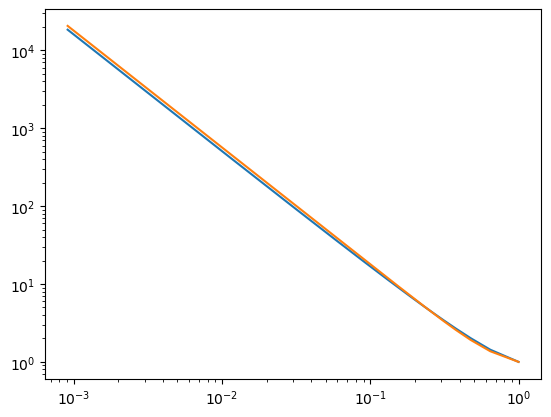

In [ ]:
h0 = 0.735
om = 0.32
c = np.array([-0.1102, 0.0256])

model = model_independent(c,aalex,h0,om,n=-1)
plt.loglog(aalex,model.model_expf())
plt.loglog(aalex,model.lcdm_expf())



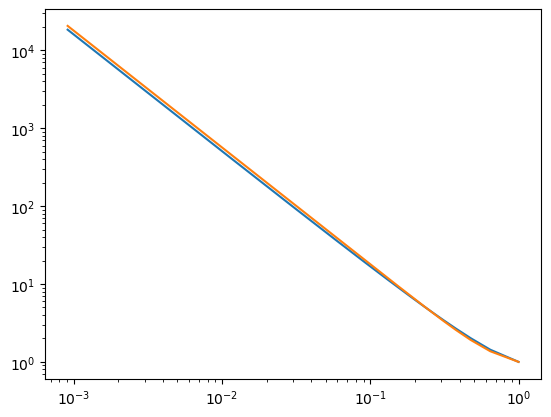

In [ ]:
c = np.array([-0.1102, 0.0256])
zalex = np.linspace(0,1100,2000)
aalex = 1/(1+zalex)
aalex = aalex[::-1]
alex = model_independent(c,aalex,h0,0.32,n)
# plt.loglog(alex.a_alex, alex.lcdm_expf())

plt.loglog(alex.a_alex,alex.model_expf_alex())
plt.loglog(alex.a,alex.lcdm_expf())

358.83679316425395
iteration 0  339.66581111450887
iteration 1000  0.03965649742362155
iteration 2000  0.002846991672964752
iteration 3000  0.0021086755591764317
iteration 4000  0.002065898574878226
iteration 5000  0.0020627957524683212
iteration 6000  0.0020625706686545416
iteration 7000  0.0020625546760949507
iteration 8000  0.002062553565289185
iteration 9000  0.002062553489904683
iteration 10000  0.002062553484907818
[ 0.70074766 -0.13619245 -0.02079302  0.00531602]


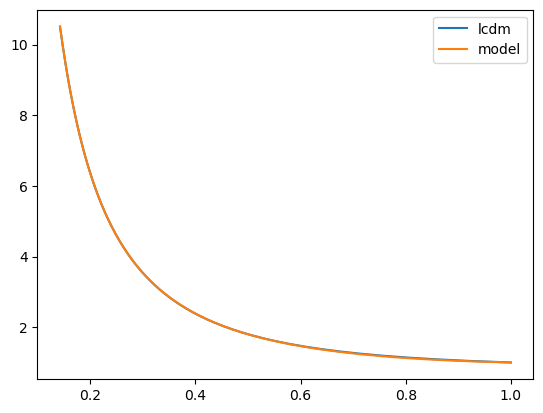

In [ ]:
## Fitting model expansion function to LCDM

c = np.array([0.944, -0.357, 0.047,0])
a = np.loadtxt("a_bg.txt")
# a = np.linspace(0.294118,1.0,200)
me = model_independent(c,a,h0=h0_alex,om=om_alex, n=-1)

model = me.model_expf(c=c)
lcdm = me.lcdm_expf()

me.fit_model_to_lcdm(model,learning_rate=0.000005,n=10000)
print(me.c)
plt.plot(a,lcdm,label="lcdm")
plt.plot(a,me.model_expf(),label="model")
plt.legend()

30.883230596079194
iteration 0  30.735767778502215
iteration 1000  0.003911691423124114
iteration 2000  4.833508430278605e-05
iteration 3000  6.530516487265767e-06
iteration 4000  1.1912831196944323e-06
iteration 5000  2.052063516759532e-07
iteration 6000  3.317270855968814e-08
iteration 7000  5.077058561545084e-09
iteration 8000  7.38016499266168e-10
iteration 9000  1.0196355318798967e-10
iteration 10000  1.3399485993433592e-11
[ 7.05717348e-01 -1.43000765e-01 -4.45759890e-03  4.89857013e-03
 -4.62322200e-04 -1.42155325e-04  4.35716134e-05 -7.57281019e-07
 -1.87376376e-06  2.48593009e-07 -5.29464446e-08 -6.38187568e-08]


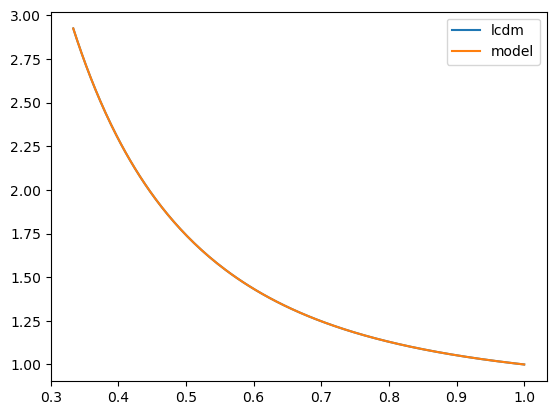

In [ ]:
## Fitting model expansion function to LCDM for z=2

c = np.array([0.944, -0.357, 0.047,0,0,0,0,0,0,0,0,0])
z = np.linspace(0.0,2.0,150)
a = 1/(1+z)
a=a[::-1]
# a = np.linspace(0.294118,1.0,200)
mee = model_independent(c,a,h0=0.6898,om=0.29044350092105475, n=-1)

model = mee.model_expf(c=c)
lcdm = mee.lcdm_expf()

mee.fit_model_to_lcdm(model,learning_rate=0.000005,n=10000)
print(mee.c)
plt.plot(a,lcdm,label="lcdm")
plt.plot(a,mee.model_expf(),label="model")
plt.legend()

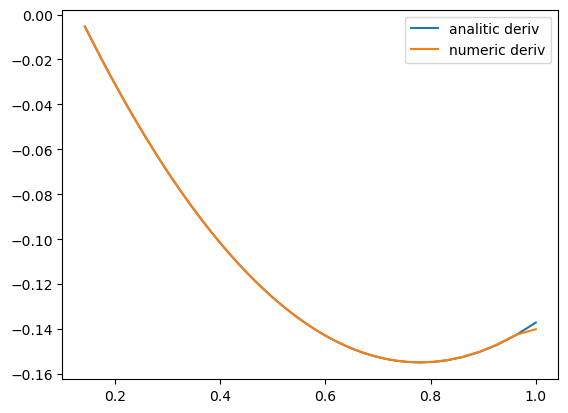

In [ ]:
## Testing the implementation of the derivative of chebyshev polynomials

analitic = mee.cheb_derivative(mee.c,2*mee.x-1)
numeric = np.gradient(mee.chebs(mee.c,2*mee.x-1),2*mee.x-1)
plt.plot(a,analitic,label='analitic deriv')
plt.plot(a,numeric,label='numeric deriv')
plt.legend()

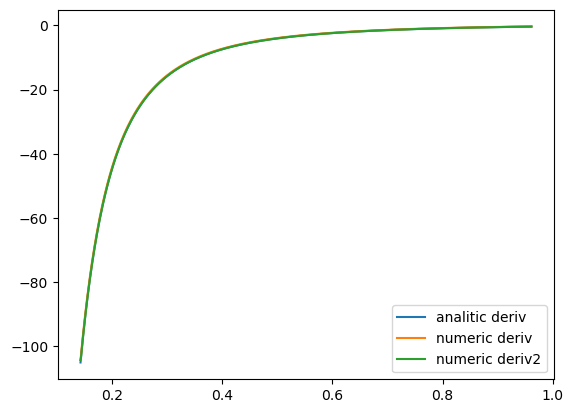

In [ ]:
## Testing  the implementation of the derivative of the expansion function

analitic = mee.d_expansion_function_d_a()
numeric1 = np.diff(mee.model_expf())/np.diff(a)
numeric2 = np.gradient(mee.model_expf(),mee.a)
expf = mee.model_expf()
# plt.loglog(me.a,expf,label='model expf')
# plt.loglog(me.a,me.lcdm_expf(),label='lcdm expf')
plt.plot(a[:-1],analitic[:-1],label='analitic deriv')
plt.plot(a[:-1],numeric1,label='numeric deriv')
plt.plot(a[:-1],numeric2[:-1],label='numeric deriv2')
plt.legend()

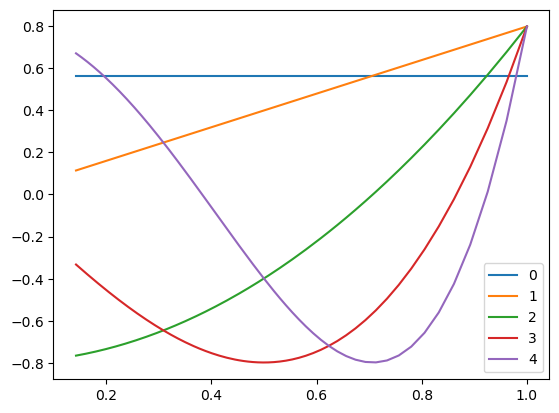

In [ ]:
## Plotting the shape of n-th order chebyshev polynomial

for i in range(5) :
    plt.plot(a,mee.cheb(i,a),label=f"{i}")
plt.legend()

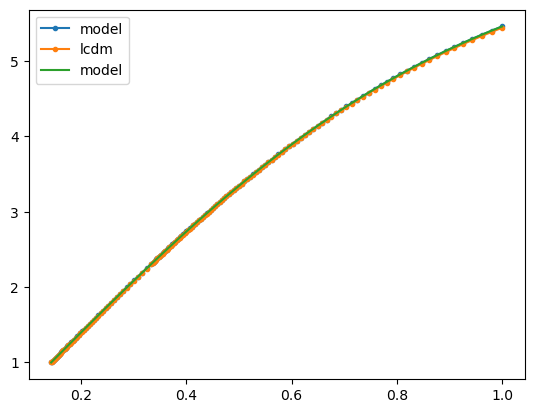

In [ ]:
## Testing the implementation of Growth Factor

zm = np.loadtxt("z_matterme.txt")
am = 1/(1+zm)[::-1]
dplus = Growth_Factor(mee.c,am,h0=0.6898,om=0.29044350092105475,n=-1)
dpl_kids = np.loadtxt('dpl_kids.txt')[::-1]
dpl_kids = dpl_kids/dpl_kids[0]
Dplus = []
Dpluss = []

for i in dplus.a :
    Dplus.append(dplus.growth_factor(i))
    Dpluss.append(dplus.D_plus(i))
Dpluss = np.array(Dpluss)
Dpluss = Dpluss/Dpluss[0]
Dplus = np.array(Dplus)
Dplus = Dplus/Dplus[0]
plt.plot(dplus.a,Dplus,label='model',marker='.')
plt.plot(dplus.a,dpl_kids,label='lcdm',marker='.')
plt.plot(dplus.a,Dpluss,label='model')
plt.legend()
# plt.plot(a,)

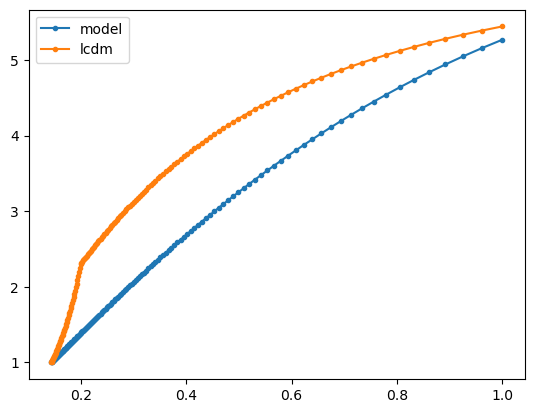

In [ ]:
## Testing the implementation of Growth Factor Alex

dplus = Growth_Factor_Alex(om = 0.32)
dpl_kids = np.loadtxt('dpl_kids.txt')[::-1]
dpl_kids = dpl_kids/dpl_kids[0]
Dplus = []

for i in dplus.a :
    Dplus.append(dplus.growth_factor(i))
Dplus = np.array(Dplus)
Dplus = Dplus/Dplus[0]
plt.plot(dplus.a,Dplus,label='model',marker='.')
plt.plot(dplus.a,dpl_kids,label='lcdm',marker='.')
plt.legend()

difference from chain (grad_des, like : -49.82680775609994) : 1.256547078662853e-08
difference from lcdm 60 (grad_des, like : -49.82680775609994) : 9.564538007841404e-09
difference from chain (best like : -48.091703978398) : 9.515276571162245e-09
difference from lcdm 60 (best like : -48.091703978398) : 9.564538007841404e-09
difference from chain (worst like : -182924.87667928817) : 3.0429130694189963e-06
difference from lcdm 60 (worst like : -182924.87667928817) : 9.564538007841404e-09
difference from chain (good like : -47.39) : 9.803273663502498e-09
difference from lcdm 60 (good like : -47.39) : 9.564538007841404e-09


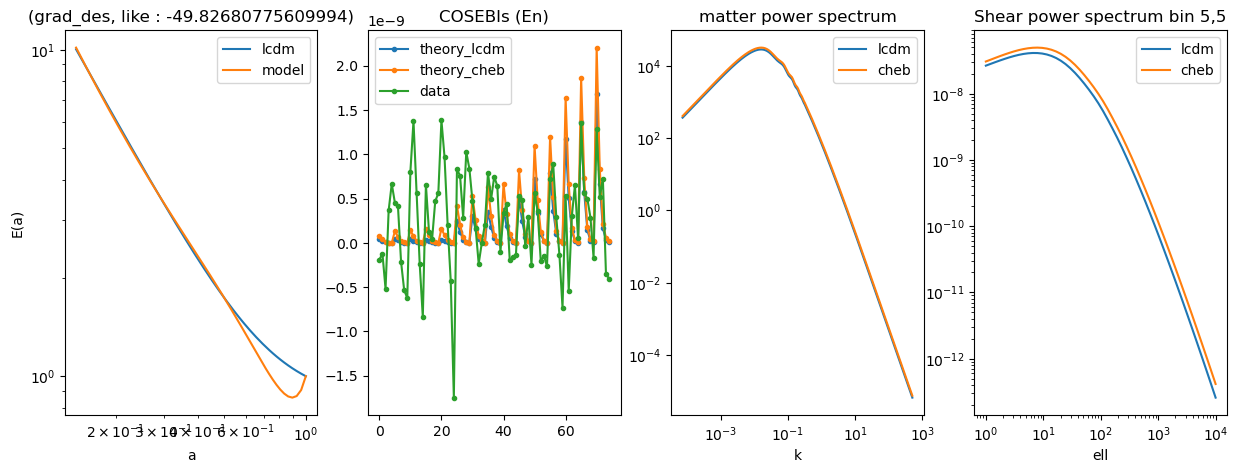

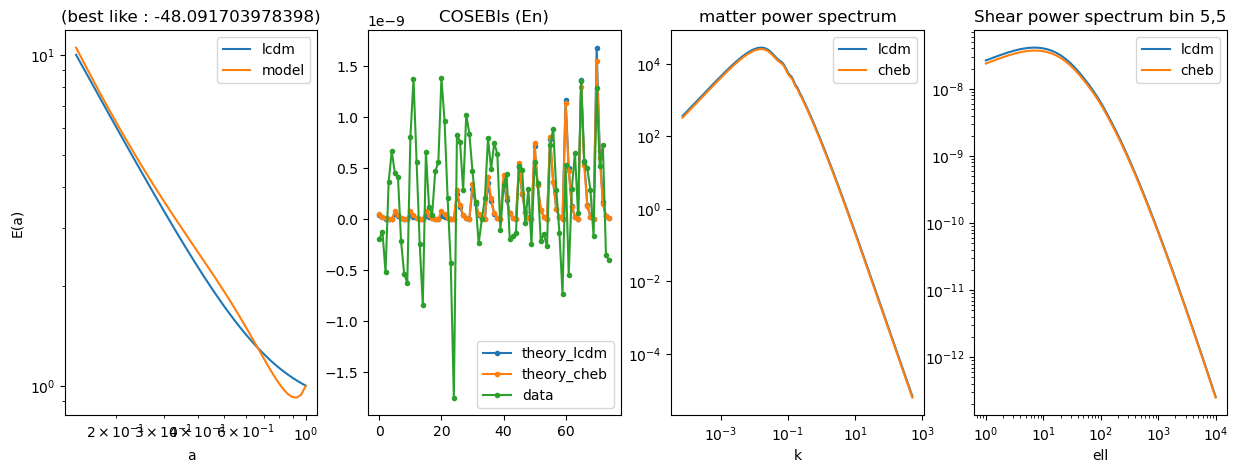

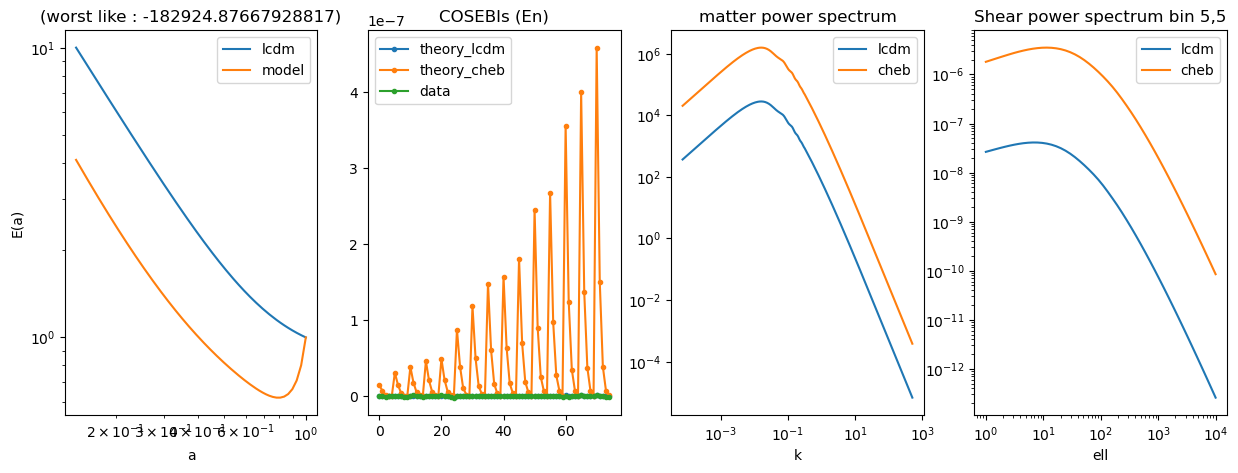

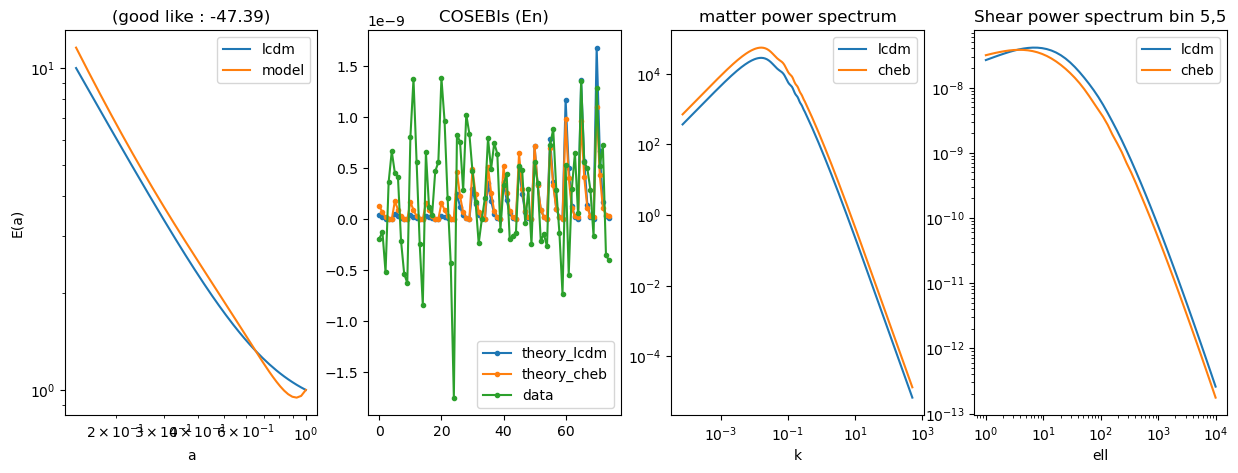

In [ ]:
mee = model_independent(c,a,n=0)
def combine(c,theory,pm,cell, comment="") :
    k = np.loadtxt("k_hme.txt")
    a = np.loadtxt("a_bg.txt")
    ells = np.loadtxt("ellsme.txt")
    pm_lcdm = np.loadtxt("pm_lin_60.txt")[0]
    cell_lcdm = np.loadtxt("c_ell_lin_60.txt")
    me = model_independent(c,a,n=0)
    model = me.model_expf()
    lcdm = me.lcdm_expf()
    plt.figure(figsize=(15,5))
    plt.subplot(1,4,1)
    plt.loglog(a,lcdm,label="lcdm")
    plt.loglog(a,model,label="model")
    # plt.xlim(0.5,1)
    plt.ylabel("E(a)")
    plt.xlabel("a")
    plt.title(comment)
    plt.legend()

    dt60 = np.loadtxt("data-theory_data60_theory60.txt")
    diff_best_like = np.abs(theory-dt60[:,0])
    diff_lcdm_60 = np.abs(dt60[:,1]-dt60[:,0])
    n=40
    print("difference from chain", comment, ":", np.sum(diff_best_like[n:]))
    print("difference from lcdm 60", comment, ":" , np.sum(diff_lcdm_60[n:]))
    plt.subplot(1,4,2)
    plt.plot(dt60[:,1],label="theory_lcdm",marker = '.')
    plt.plot(theory, label = "theory_cheb",marker='.')
    plt.plot(dt60[:,0], label = "data",marker = '.')
    plt.title("COSEBIs (En)")
    plt.legend();

    plt.subplot(1,4,3)
    plt.loglog(k,pm_lcdm,label="lcdm")
    plt.loglog(k,pm,label="cheb")
    plt.legend();
    plt.xlabel('k')
    plt.title("matter power spectrum")

    plt.subplot(1,4,4)
    plt.loglog(ells,cell_lcdm,label="lcdm")
    plt.loglog(ells,cell,label="cheb")
    plt.legend();
    plt.xlabel('ell')
    plt.title("Shear power spectrum bin 5,5")

c = np.array([0.90125145, -0.42186272,  0.10139695, -0.06361757])
theory = np.loadtxt("data-theory_grad_des_new.txt",skiprows=1)[:,1]
pm = np.loadtxt("pm_grad_des_new.txt")[0]
cell = np.loadtxt("c_ell_grad_des_new.txt")
combine(c,theory,pm,cell,"(grad_des, like : -49.82680775609994)")

c = np.array([0.9853482478718526,	-0.469695954390673,	0.13763057859793937,-0.06950337725419585])
theory_best_like = np.loadtxt("data-theory_best_like_new.txt", skiprows=1)[:,1]
pm = np.loadtxt("pm_best_like_new.txt")[0]
cell = np.loadtxt("c_ell_best_like_new.txt")
combine(c,theory_best_like,pm,cell,"(best like : -48.091703978398)")

c = np.array([1.0320677375793457,-0.6950483950972557,0.1575472903251648,-0.05516065055131912])
theory = np.loadtxt("data-theory_chain3.txt",skiprows=1)[:,1] # like = -967548.2720155459
pm = np.loadtxt("pm_worst_like_new.txt")[0]
cell = np.loadtxt("c_ell_worst_like_new.txt")
combine(c,theory,pm,cell,"(worst like : -182924.87667928817)")

c = np.array([1.3676562761732827,	-0.6177352519042305,	0.14366336161970764,	-0.06795405255128631])
theory = np.loadtxt("data-theory_chain2.txt",skiprows=1)[:,1]
pm = np.loadtxt("pm_chain2.txt")[0]
cell = np.loadtxt("c_ell_chain2.txt")
combine(c,theory,pm,cell,"(good like : -47.39)")

difference from chain (good like : -47.39) : 9.803273663502498e-09
difference from lcdm 60 (good like : -47.39) : 9.564538007841404e-09


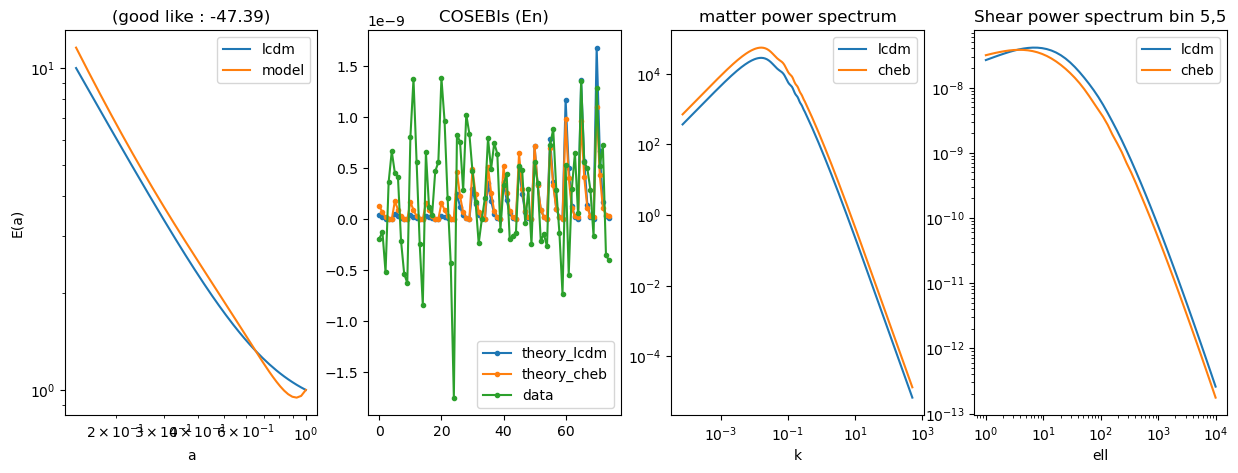

In [ ]:
report = Report()
c = np.array([1.3676562761732827,	-0.6177352519042305,	0.14366336161970764,	-0.06795405255128631])
theory = np.loadtxt("data-theory_chain2.txt",skiprows=1)[:,1]
pm = np.loadtxt("pm_chain2.txt")[0]
cell = np.loadtxt("c_ell_chain2.txt")
report.combine(c,theory,pm,cell,"(good like : -47.39)")

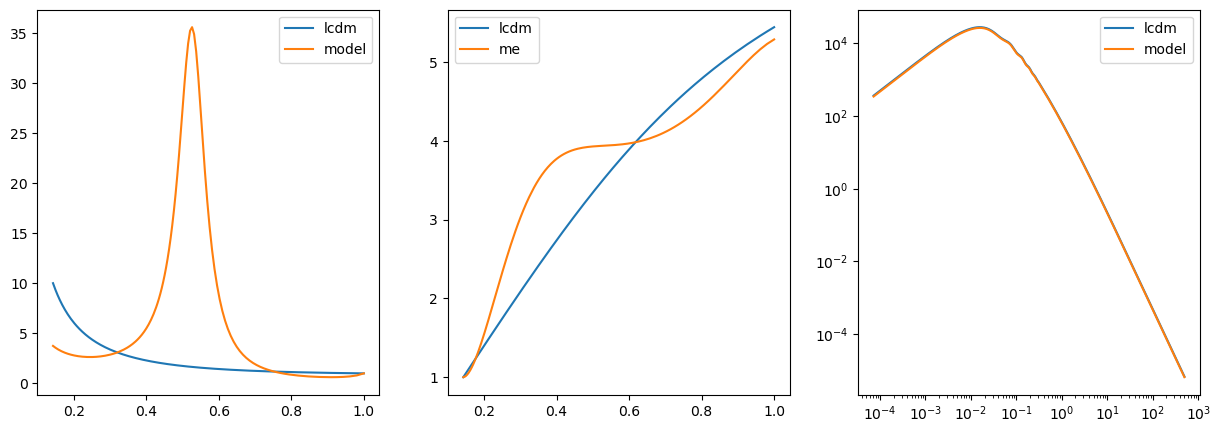

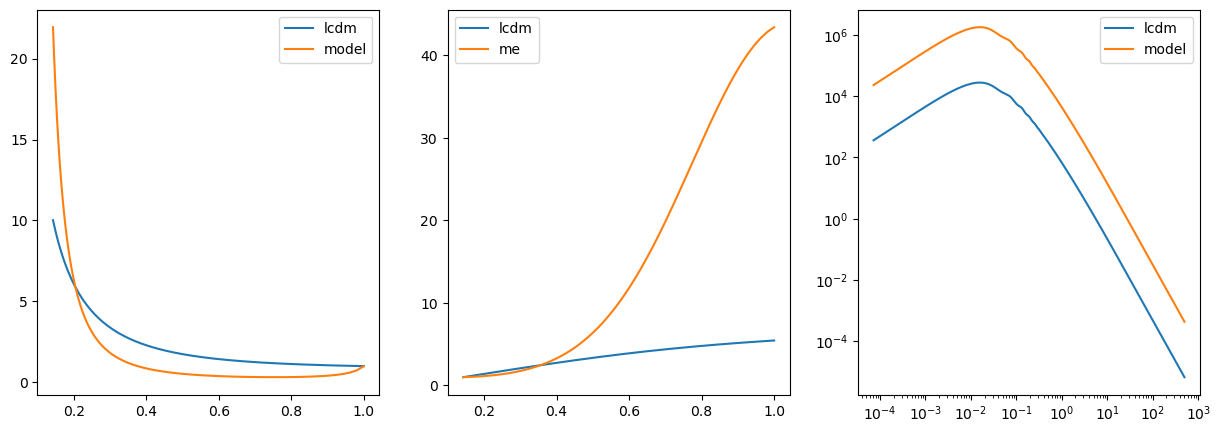

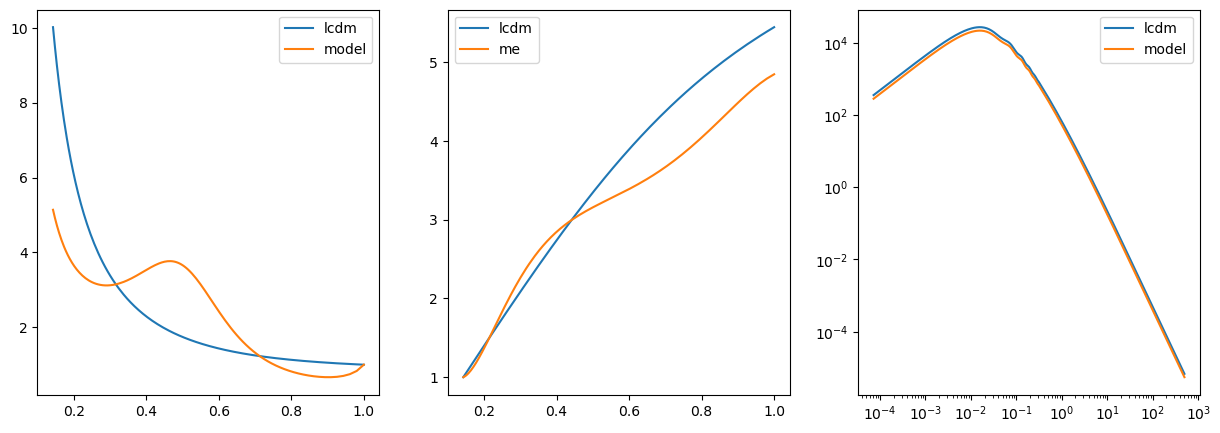

In [ ]:
zm = np.loadtxt("z_matterme.txt")
am = 1/(1+zm)[::-1]
def plot_dpl(c,pm) :
    dpl_kids = np.loadtxt('dpl_kids.txt')[::-1]
    dpl_kids = dpl_kids/dpl_kids[0]
    Dplus = Growth_Factor(c,am)
    model = model_independent(c,am)
    pm_lcdm = np.loadtxt("pm_lin_60.txt")[0]
    k = np.loadtxt("k_hme.txt")
    dpl = []
    for i in am :
        dpl.append(Dplus.D_plus(i))
    dpl = np.array(dpl) / dpl[0]
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.plot(am,model.lcdm_expf(),label="lcdm")
    plt.plot(am,model.model_expf(),label="model")
    plt.legend()
    plt.subplot(1,3,2)
    plt.plot(am,dpl_kids,label="lcdm")
    plt.plot(am,dpl,label="me")
    plt.legend()
    plt.subplot(1,3,3)
    plt.loglog(k,pm_lcdm,label="lcdm")
    plt.loglog(k,pm,label="model")
    plt.legend()

c = np.array([0.8196409397922872,-0.6642815121383635,0.5504582434204637,-0.3052315604436191])
pm = np.loadtxt("pm_best_like_3.txt")[0]
plot_dpl(c,pm)
c = np.array([1.1057156324386597,	-0.17641925811767578,	-0.5018882751464844,	0.06964702606201167])
pm = np.loadtxt("pm_worst_like_3.txt")[0]
plot_dpl(c,pm)
c = np.array([-1.2667247001202508,	0.8507695147857159,	-0.5913284827490566,	0.3539920080841348])
pm = np.loadtxt("pm_good_like_3.txt")[0]
plot_dpl(c,pm)
# c = me.c
# pm = np.loadtxt("pm_grad_des_new.txt")[0]
# plot_dpl(c,pm)

(0.0, 10.0)

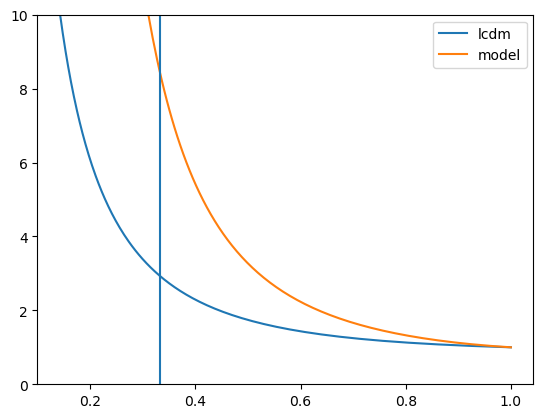

In [ ]:
c = np.array([1.4939875602722168,	0.5375677943229675,	-0.22734808921813965])
zhere = 2
ahere = 1/(1+zhere)
model = model_independent(c,a)

plt.plot(a,model.lcdm_expf(),label='lcdm')
plt.plot(a,model.model_expf(),label='model')
plt.vlines(ahere,ymin=0,ymax=10)
plt.legend()
plt.ylim(0,10)

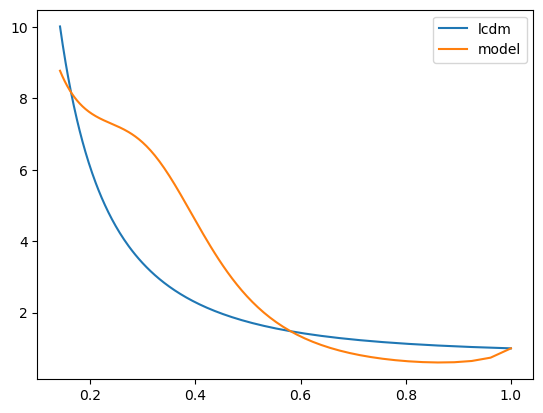

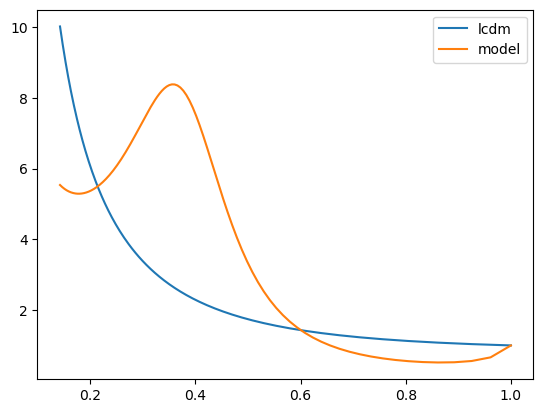

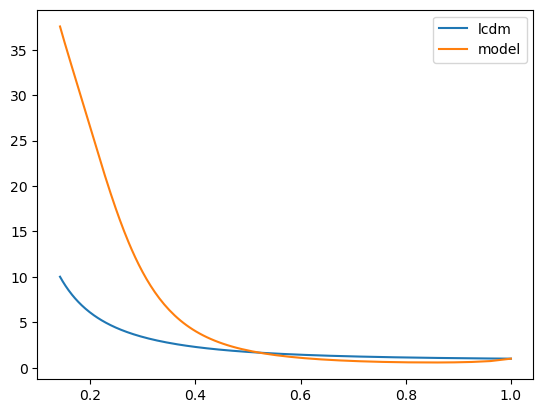

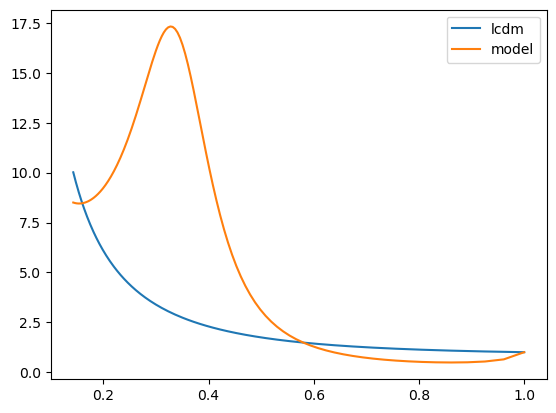

In [ ]:
c = np.array([0.8437533592851256, 0.031208185748578865, 0.014650194204474554, -0.24940567101529854])
model = model_independent(c,a)
plt.plot(a,model.lcdm_expf(),label="lcdm")
plt.plot(a,model.model_expf(),label="model")
plt.legend()
plt.show()

c = np.array([-1.0625472781067822,	0.06236168614824256,	-0.18968526511096062,	0.4455988259273109])
model = model_independent(c,a)
plt.plot(a,model.lcdm_expf(),label="lcdm")
plt.plot(a,model.model_expf(),label="model")
plt.legend()
plt.show()

c = np.array([0.6813016029072321,	0.2572318014077246,	-0.20413643278055993,	-0.16297980571723003])
model = model_independent(c,a)
plt.plot(a,model.lcdm_expf(),label="lcdm")
plt.plot(a,model.model_expf(),label="model")
plt.legend()
plt.show()

c = np.array([-1.1830954093552342,-0.22161710751024488,-0.03589566228161334,0.5450954570797719])
model = model_independent(c,a)
plt.plot(a,model.lcdm_expf(),label="lcdm")
plt.plot(a,model.model_expf(),label="model")
plt.legend()
plt.show()

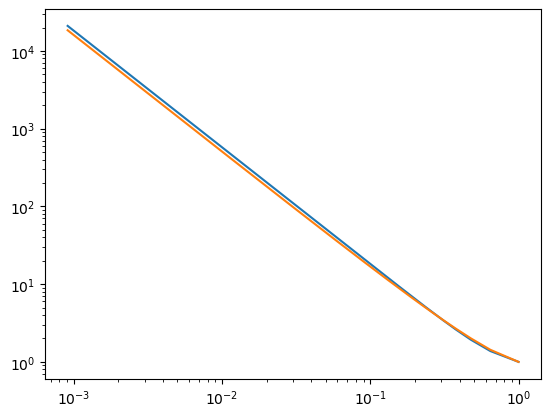

In [ ]:
z = np.linspace(0,1100,2000)
a = 1/(1+z)
a = a[::-1]
c = np.array([-0.110, 0.02561])
h0 = 0.735
om = 0.33
model = model_independent(c,a,h0,om,n=-1)

plt.loglog(a, model.lcdm_expf())
plt.loglog(a, model.model_expf())

In [ ]:
model.lcdm_comoving_distance()

array([[ 0.        , -0.        ,  0.        , -0.        ],
       [ 0.00076229, -0.00038635,  0.00045481, -0.00033995],
       [ 0.0015107 , -0.00076566,  0.00090134, -0.00067371],
       [ 0.00224498, -0.00113781,  0.00133943, -0.00100116],
       [ 0.00296491, -0.00150269,  0.00176896, -0.00132222],
       [ 0.00367033, -0.00186022,  0.00218985, -0.00163681],
       [ 0.00436118, -0.00221036,  0.00260203, -0.00194489],
       [ 0.0050374 , -0.00255308,  0.00300548, -0.00224646],
       [ 0.00569902, -0.00288841,  0.00340023, -0.00254151],
       [ 0.00634609, -0.00321637,  0.00378629, -0.00283008],
       [ 0.00697874, -0.003537  ,  0.00416375, -0.00311221],
       [ 0.00759709, -0.0038504 ,  0.00453268, -0.00338796],
       [ 0.00820132, -0.00415664,  0.00489318, -0.00365742],
       [ 0.00879164, -0.00445583,  0.00524539, -0.00392068],
       [ 0.00936828, -0.00474809,  0.00558943, -0.00417783],
       [ 0.00993148, -0.00503353,  0.00592546, -0.004429  ],
       [ 0.01048151, -0.

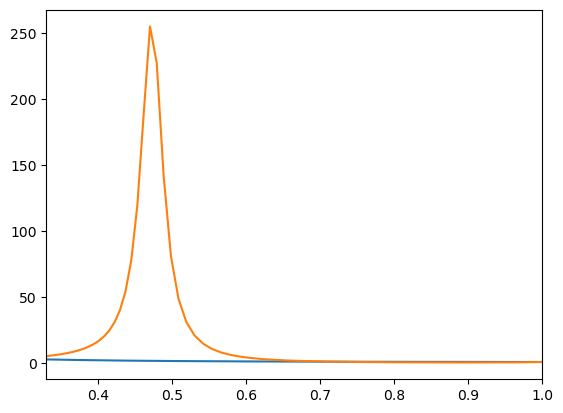

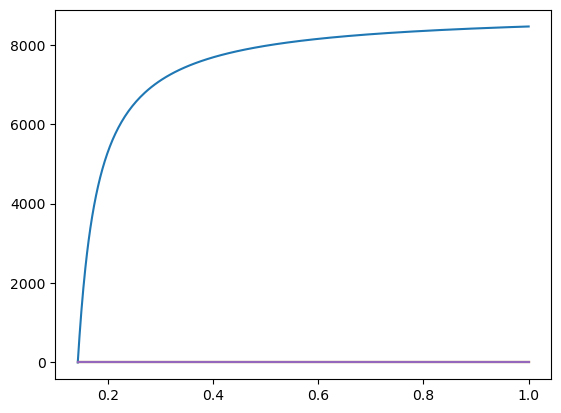

In [ ]:
c = np.array([1.3169490818825542,	-0.6674639543734385,	0.7857364522935735	,-0.5873007438564246])
z = np.linspace(0,2,100)
model = model_independent(c,a,h0,om,n)
plt.plot(a,model.lcdm_expf())
plt.plot(a,model.model_expf())
plt.xlim(0.33,1)
# plt.ylim(0,10)
plt.show()
plt.plot(a, model.lcdm_comoving_distance())
plt.plot(a, model.model_comoving_distance())

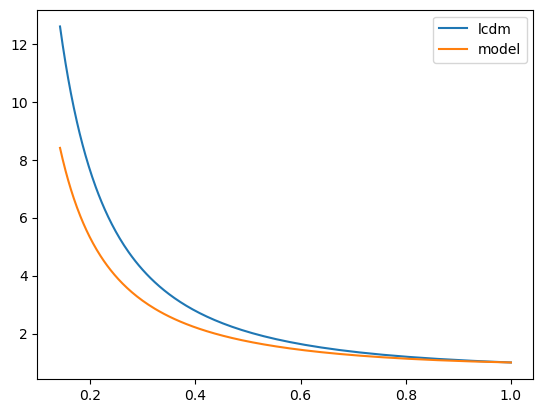

In [ ]:
c = np.array([0.11807930160702003,-0.03200332598787641,0.0017276066776909277])
h0 = 0.735
om = (0.23+0.0192)/h0**2
model = model_independent(c,a,h0,om,n=-1)

plt.plot(a,model.lcdm_expf(),label="lcdm")
plt.plot(a,model.model_expf(),label="model")
plt.legend()

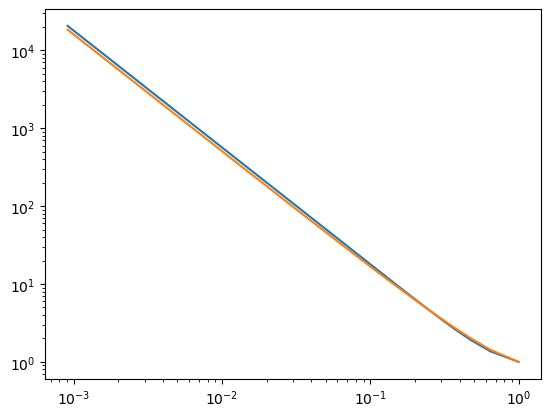

In [ ]:
model = model_independent(c_alex,a_alex,h0_alex,om_alex,n=-1)

plt.loglog(model.a,model.lcdm_expf())
plt.loglog(model.a,model.model_expf())

In [ ]:
1/7

0.14285714285714285

In [ ]:
1/1101

0.0009082652134423251

In [ ]:
25*1100

27500

In [ ]:
a

array([9.08265213e-04, 9.08301514e-04, 9.08337817e-04, ...,
       9.19114673e-01, 9.57852791e-01, 1.00000000e+00])

0.00037623070808263774


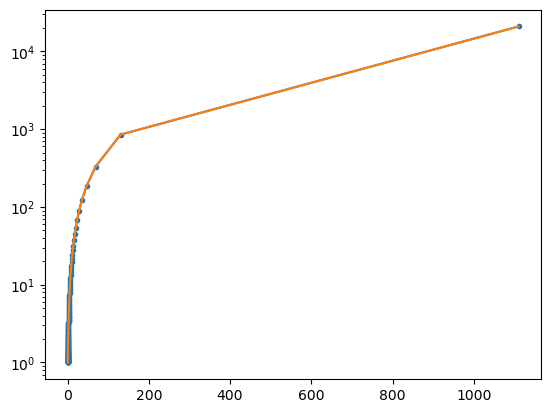

In [ ]:
a = np.linspace(0.0009,1,150)
z = 1/a -1
modell = model_independent(model.c,a,0.735,0.3200518302559119,-1)
print(np.max(np.abs(modell.model_expf()-modell.lcdm_expf())/modell.model_expf()))
plt.semilogy(z,modell.lcdm_expf(),label="lcdm",marker='.')
plt.semilogy(z,modell.model_expf(),label="model")

In [ ]:
a = np.linspace(0.0009,1,150)
z = 1/a -1


plt.semilogy(z)

In [ ]:
(0.1157+0.0225)/0.735**2

0.2558193345365357

Optimization succeeded.
Best-fit coefficients: [ 1.12260941e-01 -2.37821018e-02 -5.10613773e-03  1.59235072e-03
  4.44505926e-04 -2.16143290e-04 -1.40350697e-05  2.99964666e-05
  6.76806642e-06]
0.00042402958106651156


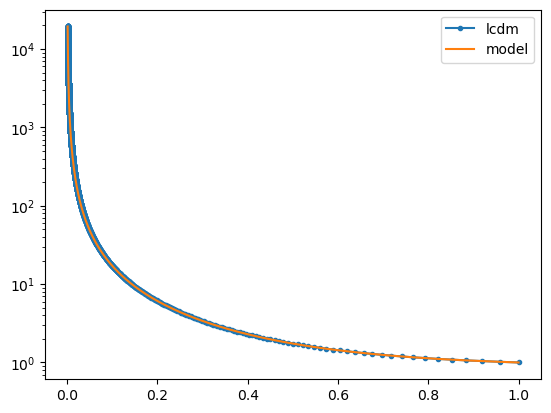

In [ ]:
c = np.array([0.1102, -0.0256,0,0,0,0,0,0,0])
z = np.linspace(0,1090.0,25000)
a = 1/(1+z)
a=a[::-1]
# a = np.linspace(0.0009,1,150)
# a = np.loadtxt("a_bg.txt")
# model = model_independent(c,a,0.735,0.3200518302559119,n=-1)
model = model_independent(c,a,0.6898,om,n=-1)
# init = model.model_expf(c=c)
# lcdm = model.lcdm_expf()

# model.fit_model_to_lcdm(init,learning_rate=0.000005,n=10000)
# print(model.c)
result = model.fit_model_to_lcdm_2()
best_fit_c = result.x
model.c = result.x

print(np.max(np.abs(model.model_expf()-model.lcdm_expf())/model.lcdm_expf()))

plt.semilogy(a,model.lcdm_expf(),label="lcdm",marker='.')
plt.semilogy(a,model.model_expf(),label="model")
plt.legend()

491.95332173194646
iteration 0  465.7804755547154
iteration 1000  0.05746768004992926
iteration 2000  0.002537486382205223
iteration 3000  0.0020782145286272254
iteration 4000  0.0020631484988320823
iteration 5000  0.0020625754895123726
iteration 6000  0.0020625542702289693
iteration 7000  0.0020625535116160863
iteration 8000  0.0020625534854604843
iteration 9000  0.0020625534845916367
iteration 10000  0.0020625534845634184
[ 0.64671216 -0.12569049 -0.01918964  0.00490609]


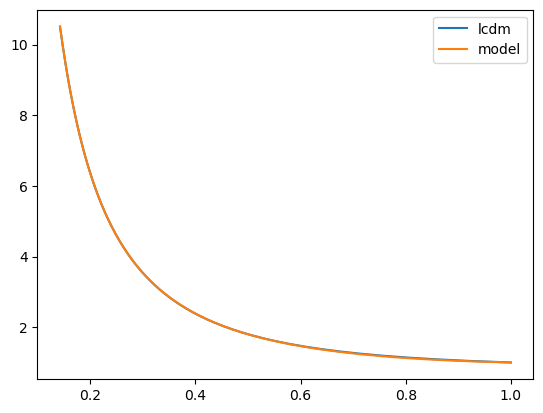

In [ ]:
## Fitting model expansion function to LCDM

c = np.array([0.944, -0.357,0,0])
a = np.loadtxt("a_bg.txt")
# a = np.linspace(0.294118,1.0,200)
me3 = model_independent(c,a,h0_alex,om_alex, n=-1)

model = me3.model_expf(c=c)
lcdm = me3.lcdm_expf()

me3.fit_model_to_lcdm(model,learning_rate=0.000005,n=10000)
print(me3.c)
plt.plot(a,lcdm,label="lcdm")
plt.plot(a,me3.model_expf(),label="model")
plt.legend()

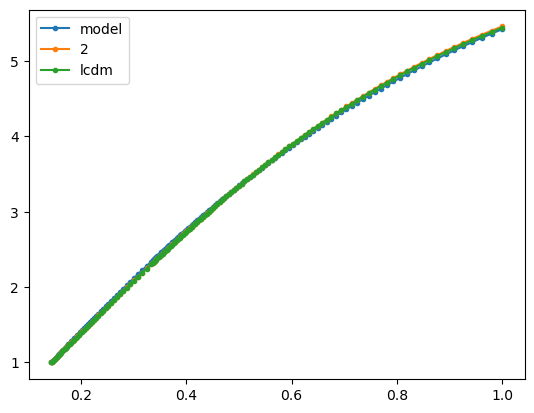

In [ ]:
## Testing the implementation of Growth Factor Alex
dplus = Growth_Factor(c_alex,a_alex,h0_alex,om_alex,n=-1)
dplus2 = Growth_Factor(me.c,a,h0,om,n=-1)
Dplus2=[]
Dplus = []

dpl_kids = np.loadtxt('dpl_kids.txt')[::-1]
dpl_kids = dpl_kids/dpl_kids[0]

zm = np.loadtxt("z_matterme.txt")
am = 1/(1+zm)[::-1]
for i in am :
    Dplus.append(dplus.growth_factor(i))
    Dplus2.append(dplus2.growth_factor(i))
Dplus = np.array(Dplus)
Dplus = Dplus/Dplus[0]
Dplus2 = np.array(Dplus2)
Dplus2 = Dplus2/Dplus2[0]
plt.plot(am,Dplus,label='model',marker='.')
plt.plot(am,Dplus2,label='2',marker='.')
plt.plot(am,dpl_kids,label='lcdm',marker='.')
plt.legend()

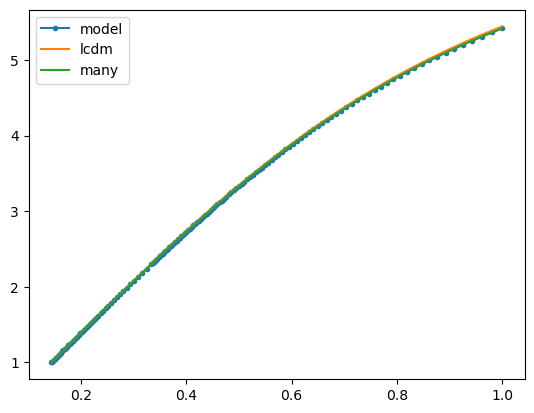

In [ ]:
## Testing the implementation of Growth Factor WEIRD

zz = np.linspace(0,1100,150)
aa = 1/(1+zz)
aa = aa[::-1]
c = np.array([1.12261054e-01, -2.37821248e-02, -5.10628795e-03 , 1.59232061e-03, 4.44512034e-04 , -2.16165502e-04 , -1.40475141e-05, 2.99948164e-05, 6.76835426e-06])
dplus = Growth_Factor(c,aa,h0,om,n=-1)
Dplus = []

dpl_kids = np.loadtxt('dpl_kids.txt')[::-1]
dpl_kids = dpl_kids/dpl_kids[0]
dpl_many = np.loadtxt("dpl_many.txt")

zm = np.loadtxt("z_matterme.txt")
am = 1/(1+zm)[::-1]
for i in am :
    Dplus.append(dplus.growth_factor(i))
Dplus = np.array(Dplus)
Dplus = Dplus/Dplus[0]
plt.plot(am,Dplus,label='model',marker='.')
plt.plot(am,dpl_kids,label='lcdm')
plt.plot(am,dpl_many,label='many')
plt.legend()

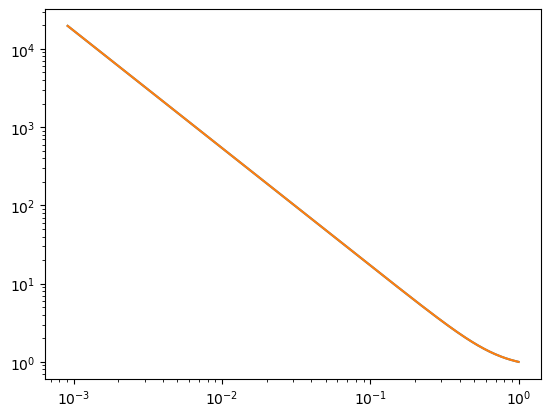

In [ ]:
plt.loglog(aa,dplus.model.lcdm_expf())
plt.loglog(aa,dplus.model.model_expf())

In [ ]:
0.0233714847462526+0.08017353077945194

0.10354501552570454

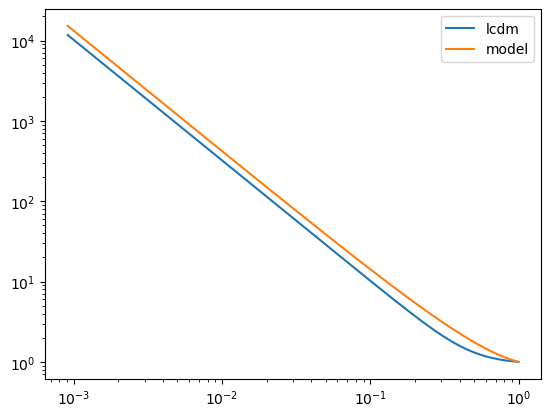

In [ ]:
c = np.array([0.11945120887469148, -0.03569548069777911,0.002406264314157723])
# c = np.array([0.119,-0.0349,0.0032])
z = np.linspace(0,1100,15000)
a = 1/(1+z)
a=a[::-1]
model = model_independent(c,a,h0_alex,0.10354,n)

plt.loglog(a,model.lcdm_expf(),label="lcdm")
plt.loglog(a,model.model_expf(),label="model")
plt.legend()

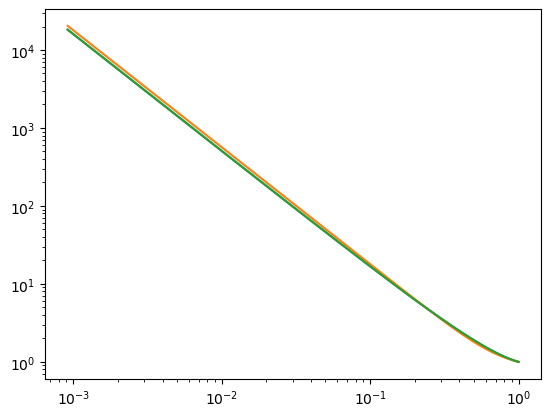

In [ ]:
zz = np.linspace(0,1090,25000)
aa = 1/(1+zz)[::-1]
# c = np.array([1.307, -0.282, 0.021])
c = np.array([0.1102 , -0.0256])
mod = model_independent(c,aa,h0_alex,0.32,-1)
lcdm = np.loadtxt("lcdm_expf.txt")
model = np.loadtxt("model_expf.txt")

plt.loglog(aa,model)
plt.loglog(aa,mod.lcdm_expf())
plt.loglog(aa,mod.model_expf())
# plt.xlim(0.1,1)
# plt.ylim(1,15)

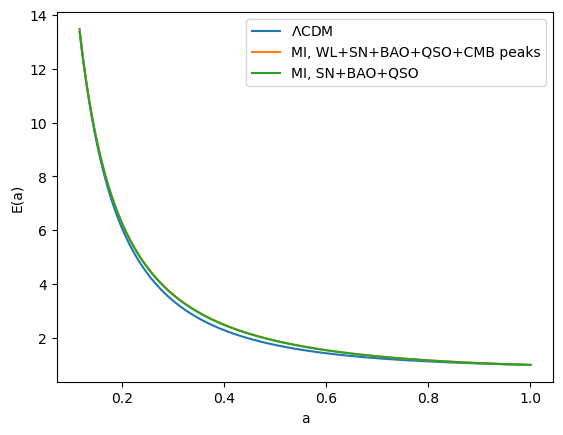

In [4]:
c = np.array([1.059,-0.2264])
c_bf= np.array([1.05754841,-0.2245601])
ahere = np.loadtxt("a_qso.txt")
model = model_independent(c,ahere,h0_alex,om_alex,n=-1)
model_bf = model_independent(c_bf,ahere,h0_alex,om_alex,n=-1)
lcdm_model = model_independent(c,ahere,0.6898,om,n=-1)
expf = np.loadtxt("expf_qso.txt")
lcdm = np.loadtxt("lcdm_expf_qso.txt")
fig, ax = plt.subplots()
init = model.model_expf()
ax.plot(ahere,lcdm_model.lcdm_expf(),label=r"$\Lambda$CDM")
ax.plot(ahere,model_bf.model_expf(),label="MI, WL+SN+BAO+QSO+CMB peaks")
ax.plot(ahere,init,label="MI, SN+BAO+QSO")
ax.set_xlabel('a')
ax.set_ylabel("E(a)")
# ax.axvline(0.5,0,1,color = "k", linestyle="--", clip_on = False)
ax.legend()
plt.savefig("joint expf.pdf")

In [ ]:
h0_alex

0.735

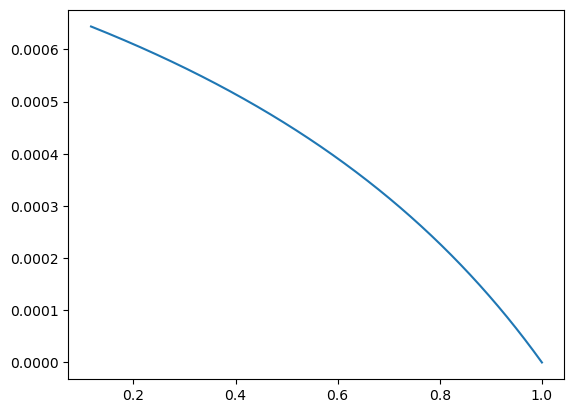

In [ ]:
plt.plot(ahere,(init-expf)/expf)


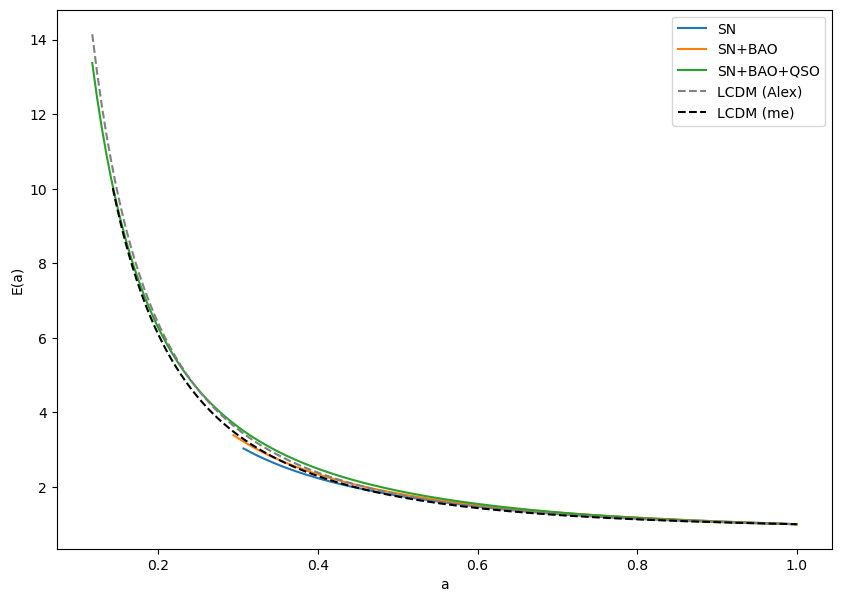

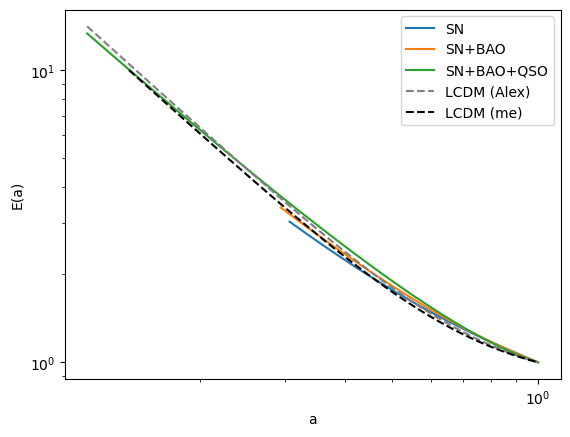

In [4]:
c_sn = np.array([1.34,-0.314,0.033])
err_sn = np.array([0.051, 0.061, 0.028])
c_sn_bao = np.array([1.307,-0.282,0.021])
err_sn_bao = np.array([0.021, 0.029, 0.015])
c_sn_bao_qso = np.array([1.059,-0.2264])
err_sn_bao_qso = np.array([0.012,0.0087])
c_wl = np.array([1.4770059882545024, 0.08385879725217815,
              -0.09550484552979466, 0.09726567193865776])
c_wl2 = np.array([1.4166690600528997, 0.09674511238932615,
                  0.025517857074737527, 0.0871104557764068])
err_wl = np.array([2.5828275884640113, 0.7377970367606501,
                  0.4880022863771738, 0.5993570980288796])
err_wl2 = np.array([2.5173219932471143, 0.6952156513254726,
                  0.4576394995596407, 0.6052567547078322])
c_joint = np.array([1.06, -0.225])
err_joint = np.array([0.0194,0.0133])

a_min_sn = 0.306626 
a_min_bao = 0.294118 
a_min_cmb = 0.00091659
a_min_qso = 0.11708

a_sn = np.linspace(a_min_sn,1.0,150)
a_sn_bao = np.linspace(a_min_bao,1.0,150)
a_sn_bao_qso = np.linspace(a_min_qso,1.0,150)
a_wl = a

model_sn = model_independent(c_sn,a_sn,h0_alex,om_alex,n=-1)
model_sn_bao = model_independent(c_sn_bao,a_sn_bao,h0_alex,om_alex,n=-1)
model_sn_bao_qso = model_independent(c_sn_bao_qso,a_sn_bao_qso,h0_alex,om_alex,n=-1)
model_me = model_independent(c_sn_bao_qso,a,h0,om,n=-1)
model_wl = model_independent(c_wl,a_wl,h0,om,n=-1)
model_wl2 = model_independent(c_wl2,a_wl,h0,om,n=-1)
model_joint = model_independent(c_joint,a_wl,h0,om,n=-1)

plt.figure(figsize=(10,7))

plt.plot(a_sn,model_sn.model_expf(),label="SN")
plt.plot(a_sn_bao,model_sn_bao.model_expf(),label="SN+BAO")
plt.plot(a_sn_bao_qso,model_sn_bao_qso.model_expf(),label="SN+BAO+QSO")
plt.plot(a_sn_bao_qso,model_sn_bao_qso.lcdm_expf(),label="LCDM (Alex)",ls="--",color="Grey")
plt.plot(a,model_me.lcdm_expf(),label="LCDM (me)", ls="--",color="Black")
plt.xlabel("a")
plt.ylabel("E(a)")
plt.legend()
plt.show()

plt.loglog(a_sn,model_sn.model_expf(),label="SN")
plt.loglog(a_sn_bao,model_sn_bao.model_expf(),label="SN+BAO")
plt.loglog(a_sn_bao_qso,model_sn_bao_qso.model_expf(),label="SN+BAO+QSO")
plt.loglog(a_sn_bao_qso,model_sn_bao_qso.lcdm_expf(),label="LCDM (Alex)",ls="--",color="Grey")
plt.loglog(a,model_me.lcdm_expf(),label="LCDM (me)",ls="--",color="Black")
plt.xlabel("a")
plt.ylabel("E(a)")
plt.legend()
plt.show()

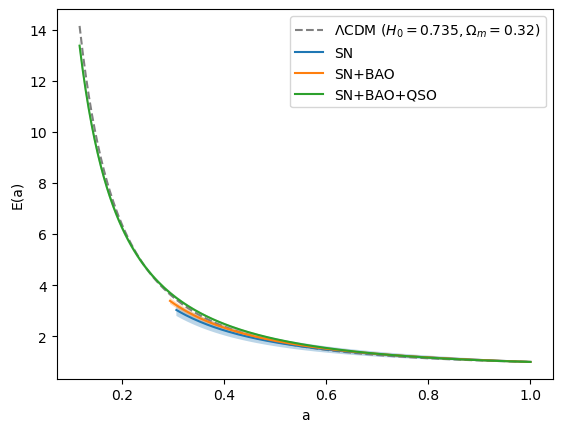

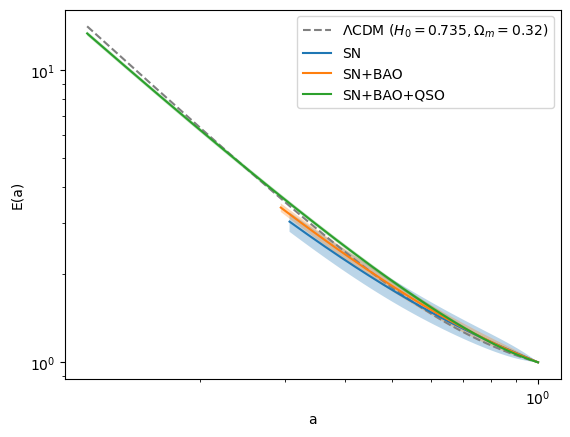

In [6]:
# Errors in model-independent expansion function
def expf_error (c,err_c,a) :
    model = model_independent(c,a,h0_alex,om_alex,n=-1)
    J = np.zeros((c.shape[0],a.shape[0])) # inside the square root
    for i in range(c.size) :
        J[i] = err_c[i]* np.polynomial.chebyshev.Chebyshev.basis(i)(2*model.x - 1) #model.cheb(i,2*model.x-1)
    delta_e = np.sqrt(np.sum(J**2,axis=0))
    delta_expf = model.model_expf()/model.chebs(c,2*model.x-1) * delta_e
    delta_expf_norm = 1/model.model_expf()[-1] * (delta_expf - delta_expf[-1] * model.model_expf()/model.model_expf()[-1])
    return delta_expf_norm

expf_sn = model_sn.model_expf()
expf_sn_bao = model_sn_bao.model_expf()
expf_sn_bao_qso = model_sn_bao_qso.model_expf()
expf_err_sn = expf_error(c_sn,err_sn,a_sn)
expf_err_sn_bao = expf_error(c_sn_bao,err_sn_bao,a_sn_bao)
expf_err_sn_bao_qso = expf_error(c_sn_bao_qso,err_sn_bao_qso,a_sn_bao_qso)

# plt.loglog(a,model_me.lcdm_expf(),label="LCDM (me)",ls="--",color="Black")
plt.plot(a_sn_bao_qso,model_sn_bao_qso.lcdm_expf(),label=r"$\Lambda$CDM ($H_0=0.735, \Omega_m= 0.32$)",ls="--",color="Grey")
plt.plot(a_sn,expf_sn,label="SN")
plt.fill_between(a_sn, expf_sn-expf_err_sn, expf_sn+expf_err_sn,alpha=0.3)
plt.plot(a_sn_bao,expf_sn_bao,label="SN+BAO")
plt.fill_between(a_sn_bao, expf_sn_bao-expf_err_sn_bao, expf_sn_bao+expf_err_sn_bao,alpha=0.3)
plt.plot(a_sn_bao_qso,expf_sn_bao_qso,label="SN+BAO+QSO")
plt.fill_between(a_sn_bao_qso, expf_sn_bao_qso-expf_err_sn_bao_qso, expf_sn_bao_qso+expf_err_sn_bao_qso,alpha=0.3)
plt.legend()
plt.xlabel("a")
plt.ylabel("E(a)")
plt.savefig("Alex_expf.pdf")
plt.show()

plt.loglog(a_sn_bao_qso,model_sn_bao_qso.lcdm_expf(),label=r"$\Lambda$CDM ($H_0=0.735, \Omega_m= 0.32$)",ls="--",color="Grey")
plt.loglog(a_sn,expf_sn,label="SN")
plt.fill_between(a_sn, expf_sn-expf_err_sn, expf_sn+expf_err_sn,alpha=0.3)
plt.loglog(a_sn_bao,expf_sn_bao,label="SN+BAO")
plt.fill_between(a_sn_bao, expf_sn_bao-expf_err_sn_bao, expf_sn_bao+expf_err_sn_bao,alpha=0.3)
plt.loglog(a_sn_bao_qso,expf_sn_bao_qso,label="SN+BAO+QSO")
plt.fill_between(a_sn_bao_qso, expf_sn_bao_qso-expf_err_sn_bao_qso, expf_sn_bao_qso+expf_err_sn_bao_qso,alpha=0.3)
plt.legend()
plt.xlabel("a")
plt.ylabel("E(a)")
plt.show()

Expansion function reconstruction using Weak Lensing

In [87]:
om

0.29044350092105475

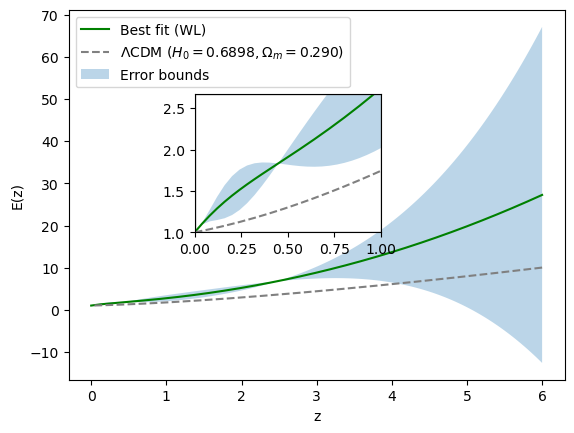

In [7]:
expf_wl = model_wl.model_expf()
expf_wl2 = model_wl2.model_expf()
expf_err_wl = expf_error(c_wl,err_wl,a_wl)
expf_err_wl2 = expf_error(c_wl2,err_wl2,a_wl)
z_wl = (1-a_wl)/a_wl

plt.plot(z_wl,expf_wl,label="Best fit (WL)", color="green")
plt.plot(z_wl,model_wl.lcdm_expf(),label=r"$\Lambda$CDM ($H_0=0.6898, \Omega_m= 0.290$)",ls="--",color="Grey")
plt.fill_between(z_wl,expf_wl-expf_err_wl,expf_wl+expf_err_wl,alpha=0.3, label="Error bounds")
plt.xlabel("z")
plt.ylabel("E(z)")
plt.legend(fontsize=10)
# plt.ylim(0,20)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
# Create inset axes
axins = inset_axes(plt.gca(), width="50%", height="50%", 
                   bbox_to_anchor=(0.24, 0.38, 0.75, 0.75),  # (x0, y0, width, height)
                   bbox_transform=plt.gca().transAxes, 
                   loc="lower left")
# loc can be: 'upper left', 'upper right', etc.

# Plot same data in the inset
axins.plot(z_wl, expf_wl, color="green")
axins.plot(z_wl,model_wl.lcdm_expf(),label=r"$\Lambda$CDM ($H_0=0.6898, \Omega_m= 0.290$)",ls="--",color="Grey")
axins.fill_between(z_wl, expf_wl-expf_err_wl, expf_wl+expf_err_wl, alpha=0.3)

# Set zoomed-in region
# axins.set_xlim(0.33, 1.0)   # <-- zoom range in a
axins.set_xlim(0, 1.0)   # <-- zoom range in z
axins.set_ylim(min(expf_wl[(a_wl>=0.5)&(a_wl<=1.0)]), 
               max(expf_wl[(a_wl>=0.5)&(a_wl<=1.0)]))
# axins.set_ylim(0,20)
# axins.set_xlabel("a")
# axins.set_ylabel("E(a)")

# Optional: add a box to indicate the zoomed region on the main plot
mark_inset(plt.gca(), axins, loc1=2, loc2=4, fc="none", ec="0.5")
plt.savefig("wl_expf.pdf")
plt.show()

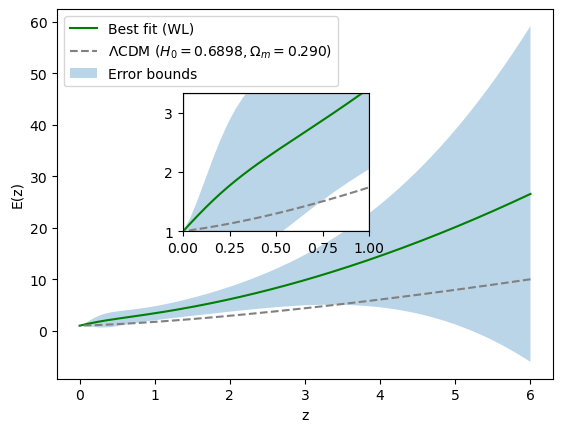

In [8]:
plt.plot(z_wl,expf_wl2,label="Best fit (WL)", color="green")
plt.plot(z_wl,model_wl2.lcdm_expf(),label=r"$\Lambda$CDM ($H_0=0.6898, \Omega_m= 0.290$)",ls="--",color="Grey")
plt.fill_between(z_wl,expf_wl2-expf_err_wl2,expf_wl2+expf_err_wl2,alpha=0.3, label="Error bounds")
plt.xlabel("z")
plt.ylabel("E(z)")
plt.legend(fontsize=10)
# plt.ylim(0,20)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
# Create inset axes
axins = inset_axes(plt.gca(), width="50%", height="50%", 
                   bbox_to_anchor=(0.24, 0.38, 0.75, 0.75),  # (x0, y0, width, height)
                   bbox_transform=plt.gca().transAxes, 
                   loc="lower left")
# loc can be: 'upper left', 'upper right', etc.

# Plot same data in the inset
axins.plot(z_wl, expf_wl2, color="green")
axins.plot(z_wl,model_wl2.lcdm_expf(),label=r"$\Lambda$CDM ($H_0=0.6898, \Omega_m= 0.290$)",ls="--",color="Grey")
axins.fill_between(z_wl, expf_wl2-expf_err_wl2, expf_wl2+expf_err_wl2, alpha=0.3)

# Set zoomed-in region
# axins.set_xlim(0.33, 1.0)   # <-- zoom range in a
axins.set_xlim(0, 1.0)   # <-- zoom range in z
axins.set_ylim(min(expf_wl2[(a_wl>=0.5)&(a_wl<=1.0)]), 
               max(expf_wl2[(a_wl>=0.5)&(a_wl<=1.0)]))
# axins.set_ylim(0,20)
# axins.set_xlabel("a")
# axins.set_ylabel("E(a)")

# Optional: add a box to indicate the zoomed region on the main plot
mark_inset(plt.gca(), axins, loc1=2, loc2=4, fc="none", ec="0.5")
plt.savefig("wl_expf.pdf")
plt.show()

Expansion reconstruction using Joint Analysis

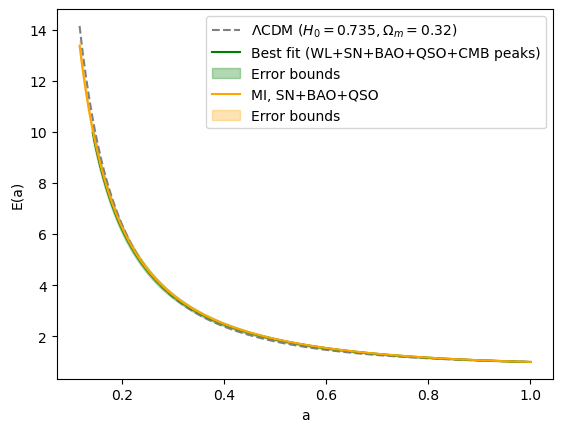

In [96]:
expf_joint = model_joint.model_expf()
expf_err_joint = expf_error(c_joint,err_joint,a_wl)

plt.plot(a_sn_bao_qso,model_sn_bao_qso.lcdm_expf(),label=r"$\Lambda$CDM ($H_0=0.735, \Omega_m= 0.32$)",ls="--",color="Grey")
plt.plot(a_wl,expf_joint,label="Best fit (WL+SN+BAO+QSO+CMB peaks)", color="green")
plt.fill_between(a_wl,expf_joint-expf_err_joint,expf_joint+expf_err_joint,alpha=0.3, color="green",label="Error bounds")
plt.plot(a_sn_bao_qso,model_sn_bao_qso.model_expf(),label="MI, SN+BAO+QSO",color="orange")
plt.fill_between(a_sn_bao_qso,expf_sn_bao_qso-expf_err_sn_bao_qso,expf_sn_bao_qso+expf_err_sn_bao_qso,alpha=0.3,color="orange",label="Error bounds")
plt.xlabel("a")
plt.ylabel("E(a)")
# plt.xlim(0.4,0.6)
plt.legend()
plt.savefig("joint_expf.pdf")


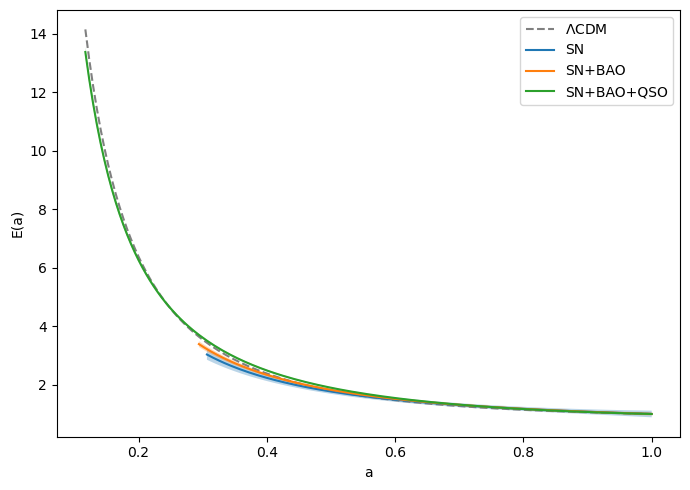

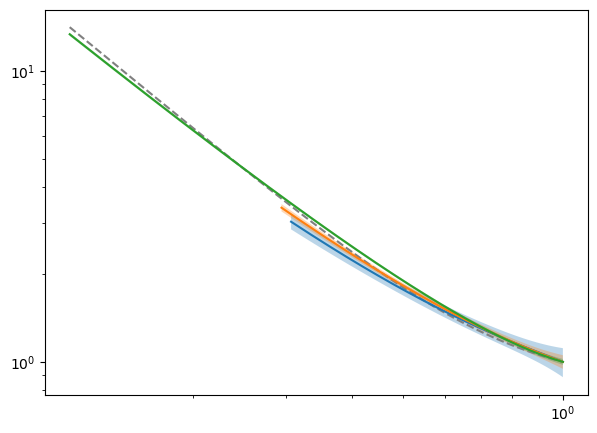

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

En_sn = model_sn.model_expf()
En_sn_bao = model_sn_bao.model_expf()
En_sn_bao_qso = model_sn_bao_qso.model_expf()
model = model_independent(c_alex,a_sn_bao_qso,h0_alex,om_alex,n=-1)

# finite-difference derivatives d y / d c_i for each parameter
eps_rel = 1e-6
num_params_sn = c_sn.size
num_params_sn_bao = c_sn_bao.size
num_params_sn_bao_qso = c_sn_bao_qso.size
J_sn = np.zeros((num_params_sn, a_sn.size))
J_sn_bao = np.zeros((num_params_sn_bao, a_sn_bao.size))
J_sn_bao_qso = np.zeros((num_params_sn_bao_qso, a_sn_bao_qso.size))
for i in range(num_params_sn):
    eps = eps_rel * (abs(c_sn[i]))
    c_plus = c_sn.copy(); c_minus = c_sn.copy()
    c_plus[i] += eps
    c_minus[i] -= eps
    y_plus = model_sn.model_expf(c=c_plus)
    y_minus = model_sn.model_expf(c=c_minus)
    J_sn[i] = (y_plus - y_minus) / (2 * eps)
for i in range(num_params_sn_bao):
    eps = eps_rel * (abs(c_sn[i]))
    c_plus = c_sn_bao.copy(); c_minus = c_sn_bao.copy()
    c_plus[i] += eps
    c_minus[i] -= eps
    y_plus = model_sn_bao.model_expf(c=c_plus)
    y_minus = model_sn_bao.model_expf(c=c_minus)
    J_sn_bao[i] = (y_plus - y_minus) / (2 * eps)
for i in range(num_params_sn_bao_qso):
    eps = eps_rel * (abs(c_sn_bao_qso[i]))
    c_plus = c_sn_bao_qso.copy(); c_minus = c_sn_bao_qso.copy()
    c_plus[i] += eps
    c_minus[i] -= eps
    y_plus = model_sn_bao_qso.model_expf(c=c_plus)
    y_minus = model_sn_bao_qso.model_expf(c=c_minus)
    J_sn_bao_qso[i] = (y_plus - y_minus) / (2 * eps)

# assume diagonal covariance = error**2 (no parameter correlations)
var_params_sn = err_sn**2
var_params_sn_bao = err_sn_bao**2
var_params_sn_bao_qso = err_sn_bao_qso**2

# propagated variance at each a: sigma_y^2 = sum_i (J_i^2 * var_i)
sigma_En_sq_sn = np.sum((J_sn**2) * var_params_sn[:, np.newaxis], axis=0)
sigma_En_sq_sn_bao = np.sum((J_sn_bao**2) * var_params_sn_bao[:, np.newaxis], axis=0)
sigma_En_sq_sn_bao_qso = np.sum((J_sn_bao_qso**2) * var_params_sn_bao_qso[:, np.newaxis], axis=0)
sigma_En_sn = np.sqrt(sigma_En_sq_sn)
sigma_En_sn_bao = np.sqrt(sigma_En_sq_sn_bao)
sigma_En_sn_bao_qso = np.sqrt(sigma_En_sq_sn_bao_qso)

plt.figure(figsize=(7,5))
plt.plot(a_sn_bao_qso, model.lcdm_expf(), label=r"$\Lambda$CDM", ls="--", color="gray")
# SN
# plt.plot(a_sn, model.lcdm_expf(), label=r"$\Lambda$CDM", linestyle="--")
plt.plot(a_sn, En_sn, label="SN")
plt.fill_between(a_sn, En_sn - sigma_En_sn, En_sn + sigma_En_sn, alpha=0.3,
                edgecolor="none")
# SN+BAO
plt.plot(a_sn_bao, En_sn_bao, label="SN+BAO")
plt.fill_between(a_sn_bao, En_sn_bao - sigma_En_sn_bao, En_sn_bao + sigma_En_sn_bao, alpha=0.3,
                 edgecolor="none")
# SN+BAO+QSO
plt.plot(a_sn_bao_qso, En_sn_bao_qso, label="SN+BAO+QSO")
plt.fill_between(a_sn_bao_qso, En_sn_bao_qso - sigma_En_sn_bao_qso, En_sn_bao_qso + sigma_En_sn_bao_qso, alpha=0.3,
                edgecolor="none")

plt.xlabel("a")
plt.ylabel("E(a)")
# plt.ylim(0,20)
plt.legend()
plt.tight_layout()
# plt.savefig("weak_lensing_expf_propagated.pdf")
plt.show()

plt.figure(figsize=(7,5))
plt.loglog(a_sn_bao_qso, model.lcdm_expf(), label=r"$\Lambda$CDM", ls="--", color="gray")
# SN
# plt.plot(a_sn, model.lcdm_expf(), label=r"$\Lambda$CDM", linestyle="--")
plt.loglog(a_sn, En_sn, label="SN")
plt.fill_between(a_sn, En_sn - sigma_En_sn, En_sn + sigma_En_sn, alpha=0.3,
                edgecolor="none")
# SN+BAO
plt.loglog(a_sn_bao, En_sn_bao, label="SN+BAO")
plt.fill_between(a_sn_bao, En_sn_bao - sigma_En_sn_bao, En_sn_bao + sigma_En_sn_bao, alpha=0.3,
                 edgecolor="none")
# SN+BAO+QSO
plt.loglog(a_sn_bao_qso, En_sn_bao_qso, label="SN+BAO+QSO")
plt.fill_between(a_sn_bao_qso, En_sn_bao_qso - sigma_En_sn_bao_qso, En_sn_bao_qso + sigma_En_sn_bao_qso, alpha=0.3,
                edgecolor="none")
plt.show()


Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


/tmp/ipykernel_75725/2538846888.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


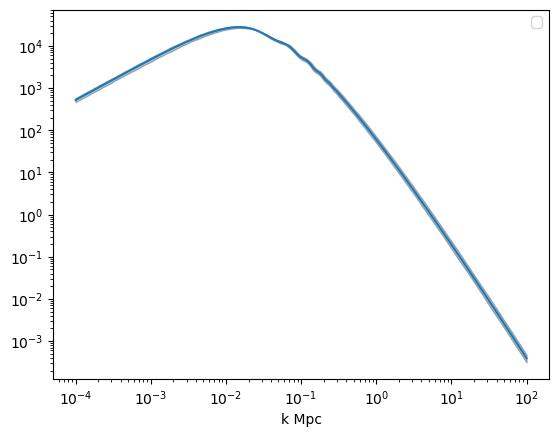

In [35]:
err = 0.1
ch2 = 0.1174
eps = 1e-6
pars = camb.set_params(H0=73.5, ombh2=0.0225, omch2=ch2, ns=0.969)
pars_plus = camb.set_params(H0=73.5, ombh2=0.0225, omch2=ch2+eps*err, ns=0.969)
pars_min = camb.set_params(H0=73.5, ombh2=0.0225, omch2=ch2-eps*err, ns=0.969)
# Note non-linear corrections couples to smaller scales than you want
z = np.linspace(0,6,150)
pars.set_matter_power(z, kmax=100.0)
pars_plus.set_matter_power(z, kmax=100.0)
pars_min.set_matter_power(z, kmax=100.0)
# Linear spectra
pars.NonLinear = camb.model.NonLinear_none
pars_plus.NonLinear = camb.model.NonLinear_none
pars_min.NonLinear = camb.model.NonLinear_none

results = camb.get_results(pars)
results_plus = camb.get_results(pars_plus)
results_min = camb.get_results(pars_min)
kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=100, npoints=200)
kh, z, pk_plus = results_plus.get_matter_power_spectrum(minkh=1e-4, maxkh=100, npoints=200)
kh, z, pk_min = results_min.get_matter_power_spectrum(minkh=1e-4, maxkh=100, npoints=200)
sigma = (pk_plus-pk_min)/(2*eps) * 0.1
index = 0
plt.loglog(kh,pk[index]) 
plt.fill_between(kh, pk[index] - sigma[index], pk[index] + sigma[index], alpha=0.3,
                 edgecolor="black")
plt.xlabel('k Mpc')
plt.legend();

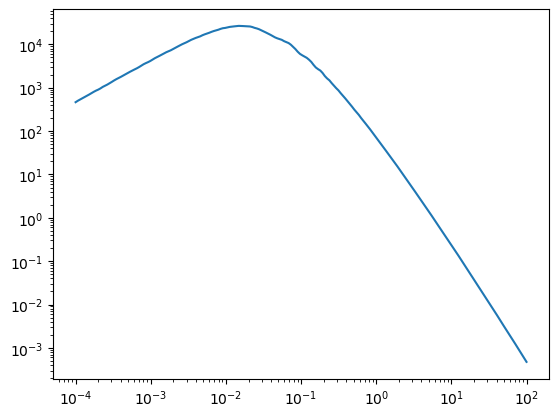

In [34]:
# plt.loglog(kh,(pk_plus-pk_min)[0]/1e-6)
plt.loglog(kh,(pk+sigma)[0])